In [8]:
# ==========================================================
# STEP 1 : IMPORT REQUIRED LIBRARIES
# ==========================================================

# Numerical Computation
import numpy as np

# Data Manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import string

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

# Set random seed for reproducibility
np.random.seed(42)

# Better plot style
plt.style.use("ggplot")

# Display all dataframe columns
pd.set_option("display.max_columns", None)

In [9]:
!pip3 install nltk

755.10s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


In [10]:
# ==========================================================
# STEP 2 : DOWNLOAD REQUIRED NLTK DATA
# ==========================================================

import nltk

nltk.download("punkt")
nltk.download("punkt_tab")      # Needed for newer NLTK versions
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/amangadhiya/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/amangadhiya/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/amangadhiya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/amangadhiya/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/amangadhiya/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [11]:
df = pd.read_csv('spam.csv' , encoding='latin-1')

In [12]:
df.shape# ==========================================================
# STEP 3 : LOAD DATASET
# ==========================================================

# Read dataset

df = pd.read_csv(
    "spam.csv",
    encoding="latin-1"
)

# Display first 5 rows
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [13]:
# ==========================================================
# STEP 4 : DATA OVERVIEW
# ==========================================================

print("="*50)
print("Dataset Shape")
print("="*50)

print(df.shape)

print("\n")

print("="*50)
print("Dataset Information")
print("="*50)

df.info()

print("\n")

print("="*50)
print("Missing Values")
print("="*50)

print(df.isnull().sum())

Dataset Shape
(5572, 5)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


Missing Values
v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64


## 1. Data Cleaning

In [14]:
df.info()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


(5572, 5)

In [15]:
# ==========================================================
# STEP 5 : REMOVE UNUSED COLUMNS
# ==========================================================

columns_to_remove = [
    "Unnamed: 2",
    "Unnamed: 3",
    "Unnamed: 4"
]

df.drop(
    columns=columns_to_remove,
    inplace=True
)

df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
# ==========================================================
# STEP 6 : RENAME COLUMNS
# ==========================================================

df.rename(
    columns={
        "v1": "target",
        "v2": "text"
    },
    inplace=True
)

df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [17]:
# renaming the cols
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(5)

,target,text
3245,ham,"Funny fact Nobody teaches volcanoes 2 erupt, t..."
944,ham,I sent my scores to sophas and i had to do sec...
1044,spam,We know someone who you know that fancies you....
2484,ham,Only if you promise your getting out as SOON a...
812,spam,Congratulations ur awarded either å£500 of CD ...


In [18]:
# ==========================================================
# STEP 7 : LABEL ENCODING
# ==========================================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["target"] = encoder.fit_transform(df["target"])

# 0 = Ham
# 1 = Spam

df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
# ==========================================================
# STEP 9 : REMOVE DUPLICATES
# ==========================================================

df = df.drop_duplicates(
    keep="first"
)

print("Duplicates Removed Successfully")

print(df.shape)

Duplicates Removed Successfully
(5169, 2)


In [20]:
# ==========================================================
# STEP 10 : FINAL DATASET SUMMARY
# ==========================================================

print("="*60)
print("FINAL DATASET INFORMATION")
print("="*60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\n")

print(df.head())

FINAL DATASET INFORMATION
Rows    : 5169
Columns : 2


   target                                               text
0       0  Go until jurong point, crazy.. Available only ...
1       0                      Ok lar... Joking wif u oni...
2       1  Free entry in 2 a wkly comp to win FA Cup fina...
3       0  U dun say so early hor... U c already then say...
4       0  Nah I don't think he goes to usf, he lives aro...


In [21]:
# ==========================================================
# STEP 11 : CLASS DISTRIBUTION
# ==========================================================

print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

print(df["target"].value_counts())

print("\n")

print(df["target"].value_counts(normalize=True) * 100)

CLASS DISTRIBUTION
target
0    4516
1     653
Name: count, dtype: int64


target
0    87.366996
1    12.633004
Name: proportion, dtype: float64


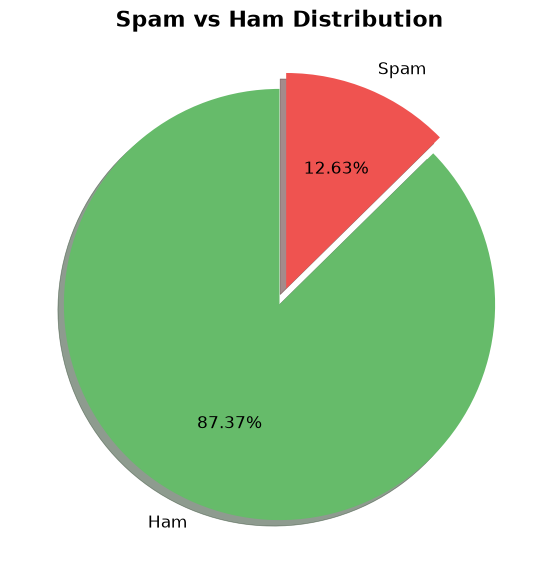

In [22]:
# ==========================================================
# STEP 12 : PIE CHART
# ==========================================================

labels = ["Ham", "Spam"]

colors = ["#66BB6A", "#EF5350"]

explode = (0, 0.08)

plt.figure(figsize=(7,7))

plt.pie(
    df["target"].value_counts(),
    labels=labels,
    autopct="%1.2f%%",
    colors=colors,
    explode=explode,
    shadow=True,
    startangle=90,
    textprops={"fontsize":12}
)

plt.title(
    "Spam vs Ham Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.show()

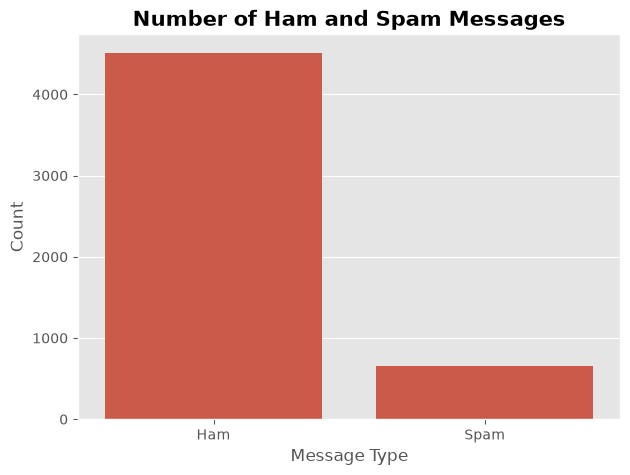

In [23]:
# ==========================================================
# STEP 13 : COUNT PLOT
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="target"
)

plt.xticks(
    [0,1],
    ["Ham","Spam"]
)

plt.title(
    "Number of Ham and Spam Messages",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Message Type")

plt.ylabel("Count")

plt.show()

In [24]:
# ==========================================================
# STEP 14 : IMPORT TOKENIZERS
# ==========================================================

from nltk.tokenize import word_tokenize

from nltk.tokenize import sent_tokenize

In [25]:
# ==========================================================
# STEP 15 : NUMBER OF CHARACTERS
# ==========================================================

df["num_characters"] = df["text"].apply(len)

## 2.EDA

In [26]:
# ==========================================================
# STEP 16 : NUMBER OF WORDS
# ==========================================================

df["num_words"] = df["text"].apply(
    lambda text: len(word_tokenize(text))
)

In [27]:
# ==========================================================
# STEP 17 : NUMBER OF SENTENCES
# ==========================================================

df["num_sentences"] = df["text"].apply(
    lambda text: len(sent_tokenize(text))
)

In [28]:
# ==========================================================
# STEP 18 : NEW FEATURES
# ==========================================================

df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [29]:
# ==========================================================
# STEP 19 : DESCRIPTIVE STATISTICS
# ==========================================================

df[
    [
        "num_characters",
        "num_words",
        "num_sentences"
    ]
].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [30]:
# ==========================================================
# STEP 20 : HAM MESSAGE STATISTICS
# ==========================================================

ham = df[df["target"] == 0]

ham[
    [
        "num_characters",
        "num_words",
        "num_sentences"
    ]
].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [31]:
# ==========================================================
# STEP 21 : SPAM MESSAGE STATISTICS
# ==========================================================

spam = df[df["target"] == 1]

spam[
    [
        "num_characters",
        "num_words",
        "num_sentences"
    ]
].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


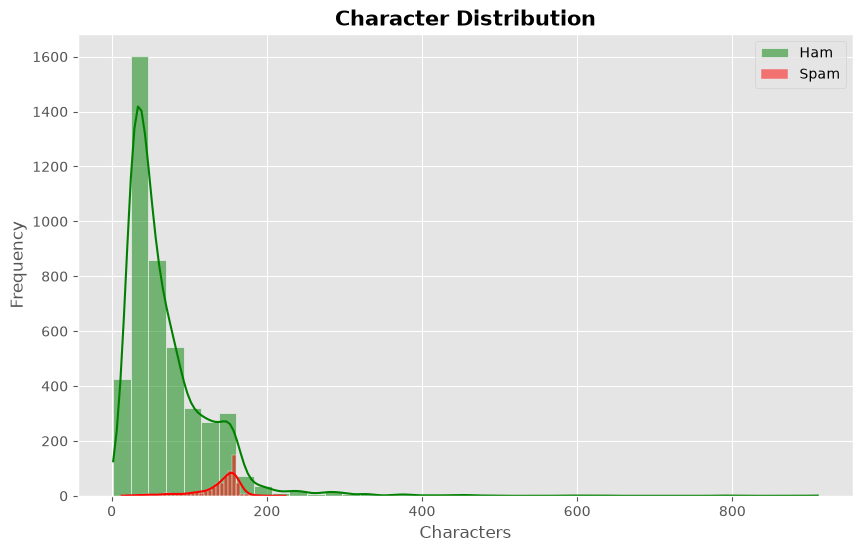

In [32]:
# ==========================================================
# STEP 22 : CHARACTER DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    ham["num_characters"],
    color="green",
    label="Ham",
    kde=True,
    bins=40
)

sns.histplot(
    spam["num_characters"],
    color="red",
    label="Spam",
    kde=True,
    bins=40
)

plt.legend()

plt.title(
    "Character Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

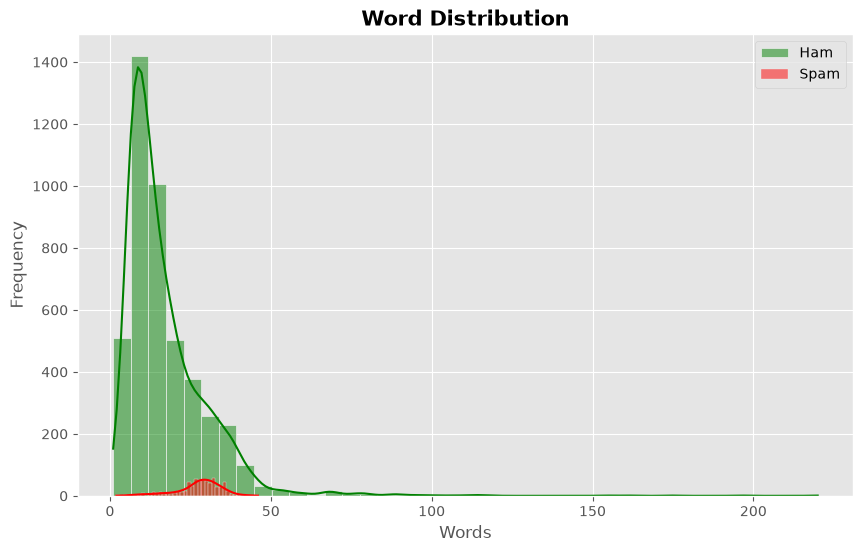

In [33]:
# ==========================================================
# STEP 23 : WORD DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    ham["num_words"],
    color="green",
    label="Ham",
    kde=True,
    bins=40
)

sns.histplot(
    spam["num_words"],
    color="red",
    label="Spam",
    kde=True,
    bins=40
)

plt.legend()

plt.title(
    "Word Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Words")

plt.ylabel("Frequency")

plt.show()

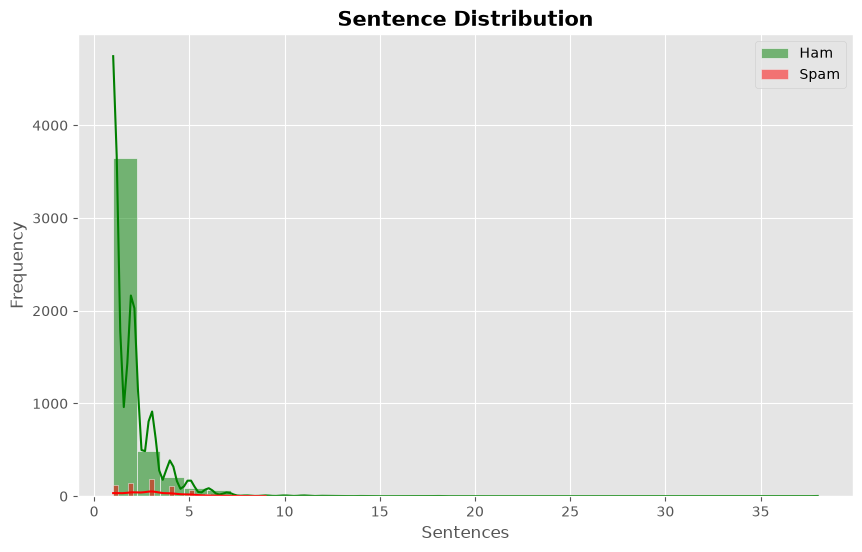

In [34]:
# ==========================================================
# STEP 24 : SENTENCE DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    ham["num_sentences"],
    color="green",
    label="Ham",
    kde=True,
    bins=30
)

sns.histplot(
    spam["num_sentences"],
    color="red",
    label="Spam",
    kde=True,
    bins=30
)

plt.legend()

plt.title(
    "Sentence Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Sentences")

plt.ylabel("Frequency")

plt.show()

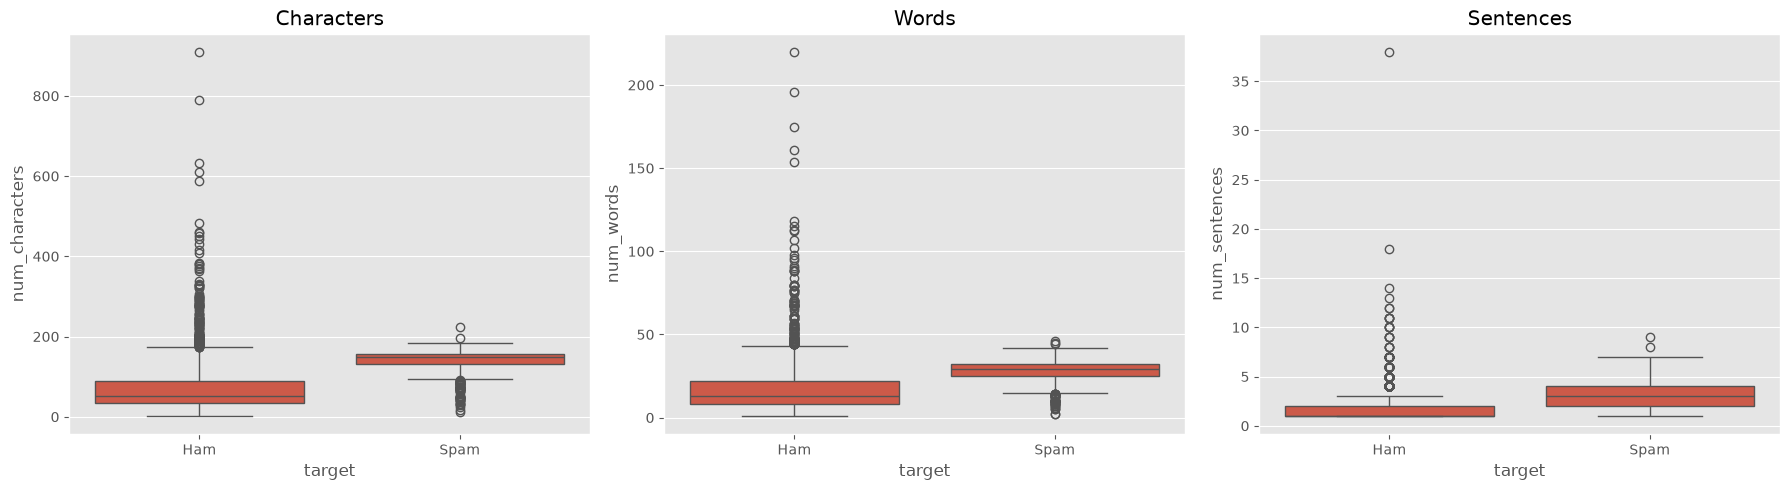

In [35]:
# ==========================================================
# STEP 25 : BOXPLOTS
# ==========================================================

fig, axes = plt.subplots(1,3,figsize=(18,5))

sns.boxplot(
    data=df,
    x="target",
    y="num_characters",
    ax=axes[0]
)

axes[0].set_xticklabels(["Ham","Spam"])

axes[0].set_title("Characters")

sns.boxplot(
    data=df,
    x="target",
    y="num_words",
    ax=axes[1]
)

axes[1].set_xticklabels(["Ham","Spam"])

axes[1].set_title("Words")

sns.boxplot(
    data=df,
    x="target",
    y="num_sentences",
    ax=axes[2]
)

axes[2].set_xticklabels(["Ham","Spam"])

axes[2].set_title("Sentences")

plt.tight_layout()

plt.show()

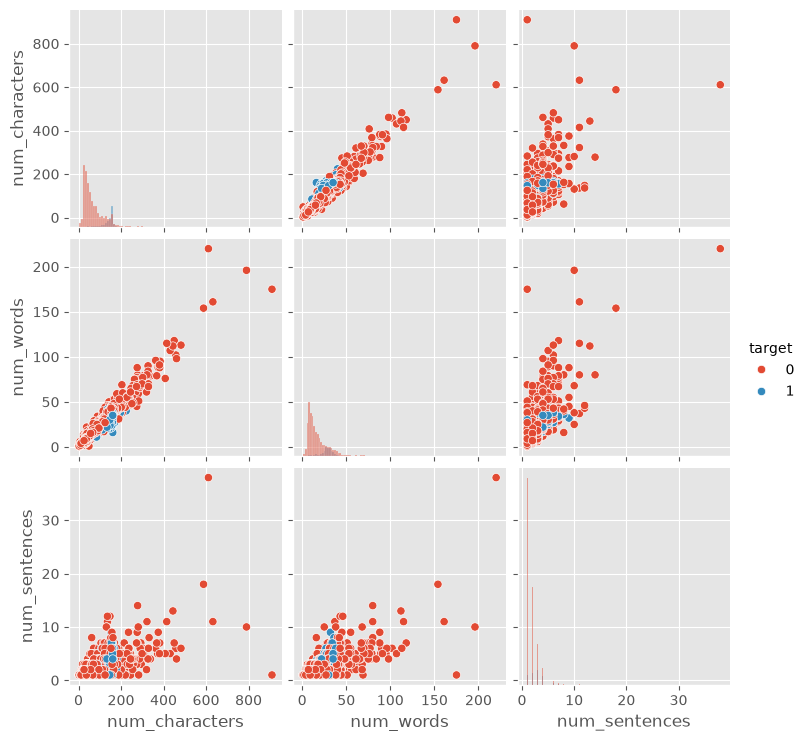

In [36]:
# ==========================================================
# STEP 26 : PAIRPLOT
# ==========================================================

sns.pairplot(
    df[
        [
            "target",
            "num_characters",
            "num_words",
            "num_sentences"
        ]
    ],
    hue="target",
    diag_kind="hist"
)

plt.show()

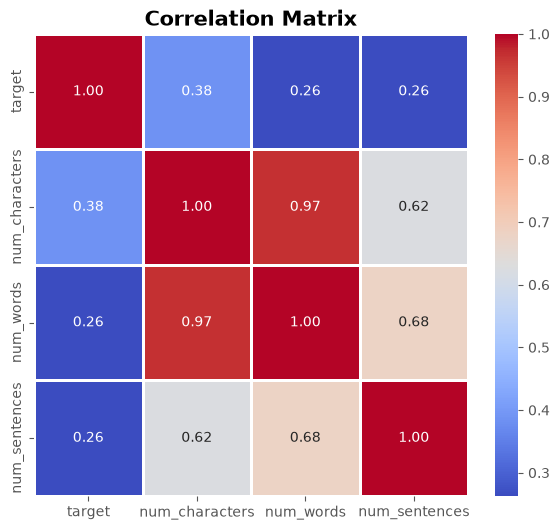

In [37]:
# ==========================================================
# STEP 27 : CORRELATION MATRIX
# ==========================================================

correlation = df[
    [
        "target",
        "num_characters",
        "num_words",
        "num_sentences"
    ]
].corr()

plt.figure(figsize=(7,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=1,
    fmt=".2f"
)

plt.title(
    "Correlation Matrix",
    fontsize=15,
    fontweight="bold"
)

plt.show()

In [38]:
# ==========================================================
# STEP 28 : TOP 10 LONGEST SMS
# ==========================================================

df.sort_values(
    "num_characters",
    ascending=False
)[
    [
        "target",
        "num_characters",
        "text"
    ]
].head(10)

,target,num_characters,text
1084,0,910,For me the love should start with attraction.i...
1862,0,790,The last thing i ever wanted to do was hurt yo...
2433,0,632,Indians r poor but India is not a poor country...
1578,0,611,How to Make a girl Happy? It's not at all diff...
2157,0,588,Sad story of a Man - Last week was my b'day. M...
2379,0,482,"Good evening Sir, hope you are having a nice d..."
3015,0,461,"&lt;#&gt; is fast approaching. So, Wish u a v..."
1512,0,458,"Hey sweet, I was wondering when you had a mome..."
2369,0,450,A Boy loved a gal. He propsd bt she didnt mind...
2407,0,444,Solve d Case : A Man Was Found Murdered On &l...


# EDA Insights

### 1. The dataset is imbalanced, with Ham messages significantly outnumbering Spam messages.

### 2. Spam messages generally contain:
- More characters
- More words
- Slightly more sentences

### 3. Word count and character count show a positive correlation.

### 4. The boxplots indicate that Spam messages tend to be longer than Ham messages.

### 5. Message length appears to be a useful feature for classification.

### 6. Text preprocessing and TF-IDF vectorization are expected to improve model performance by extracting informative textual features.

In [39]:
# ==========================================================
# STEP 30 : IMPORT NLP LIBRARIES
# ==========================================================

import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# English stopwords
stop_words = set(stopwords.words("english"))

# Lemmatizer
lemmatizer = WordNetLemmatizer()

In [40]:
# ==========================================================
# STEP 31 : TEXT CLEANING FUNCTIONS
# ==========================================================

def remove_html(text):
    """
    Remove HTML tags.
    Example:
    <p>Hello</p> -> Hello
    """
    return re.sub(r"<.*?>", "", text)


def remove_urls(text):
    """
    Remove URLs.
    """
    return re.sub(r"https?://\S+|www\.\S+", "", text)


def remove_emails(text):
    """
    Remove email addresses.
    """
    return re.sub(r"\S+@\S+", "", text)


def remove_phone_numbers(text):
    """
    Remove phone numbers.
    """
    return re.sub(r"\+?\d[\d\s\-]{7,}\d", "", text)


def remove_numbers(text):
    """
    Remove standalone numbers.
    """
    return re.sub(r"\d+", "", text)


def remove_extra_spaces(text):
    """
    Remove repeated spaces.
    """
    return re.sub(r"\s+", " ", text).strip()

In [41]:
# ==========================================================
# STEP 32 : MAIN PREPROCESSING FUNCTION
# ==========================================================

def transform_text(text):
    """
    Perform complete text preprocessing.
    """

    # Handle missing values
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove HTML
    text = remove_html(text)

    # Remove URLs
    text = remove_urls(text)

    # Remove emails
    text = remove_emails(text)

    # Remove phone numbers
    text = remove_phone_numbers(text)

    # Remove numbers
    text = remove_numbers(text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra spaces
    text = remove_extra_spaces(text)

    # Tokenize
    tokens = word_tokenize(text)

    cleaned_words = []

    for word in tokens:

        # Keep alphabetic words only
        if word.isalpha():

            # Remove stopwords
            if word not in stop_words:

                # Lemmatize
                word = lemmatizer.lemmatize(word)

                cleaned_words.append(word)

    return " ".join(cleaned_words)

In [42]:
# ==========================================================
# STEP 33 : TEST PREPROCESSING
# ==========================================================

sample_text = """ Hey Aman!! Visit https://openai.com Email me at aman@gmail.com Call me at +91-9876543210. I am LOVING machine learning! """

print("Original Text:\n")
print(sample_text)

print("\n")

print("Processed Text:\n")
print(transform_text(sample_text))

Original Text:

 Hey Aman!! Visit https://openai.com Email me at aman@gmail.com Call me at +91-9876543210. I am LOVING machine learning! 


Processed Text:

hey aman visit email call loving machine learning


In [43]:
# ==========================================================
# STEP 34 : APPLY PREPROCESSING
# ==========================================================

df["transformed_text"] = df["text"].apply(transform_text)

df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry wkly comp win fa cup final tkts st ...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah dont think go usf life around though


In [44]:
# ==========================================================
# STEP 35 : BEFORE VS AFTER
# ==========================================================

comparison = df[
    [
        "text",
        "transformed_text"
    ]
].sample(10, random_state=42)

comparison

,text,transformed_text
1617,Did u download the fring app?,u download fring app
2064,Pass dis to all ur contacts n see wat u get! R...,pas dis ur contact n see wat u get redim luv w...
1272,Ok...,ok
3020,Am in film ill call you later.,film ill call later
3642,"Sorry, left phone upstairs. OK, might be hecti...",sorry left phone upstairs ok might hectic woul...
1520,"URGENT! Your Mobile No was awarded a å£2,000 B...",urgent mobile awarded bonus caller prize nd at...
1159,Yun buying... But school got offer 2000 plus o...,yun buying school got offer plus
3986,Ringtone Club: Gr8 new polys direct to your mo...,ringtone club gr new polys direct mobile every...
3217,Don know:)this week i'm going to tirunelvai da.,knowthis week im going tirunelvai da
539,"I am in tirupur da, once you started from offi...",tirupur da started office call


In [45]:
# ==========================================================
# STEP 36 : WORD COUNT AFTER PREPROCESSING
# ==========================================================

df["clean_word_count"] = df["transformed_text"].apply(
    lambda x: len(x.split())
)

df[
    [
        "num_words",
        "clean_word_count"
    ]
].head()

,num_words,clean_word_count
0,24,16
1,8,6
2,37,20
3,13,9
4,15,8


## 3. Data Preprocessing
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

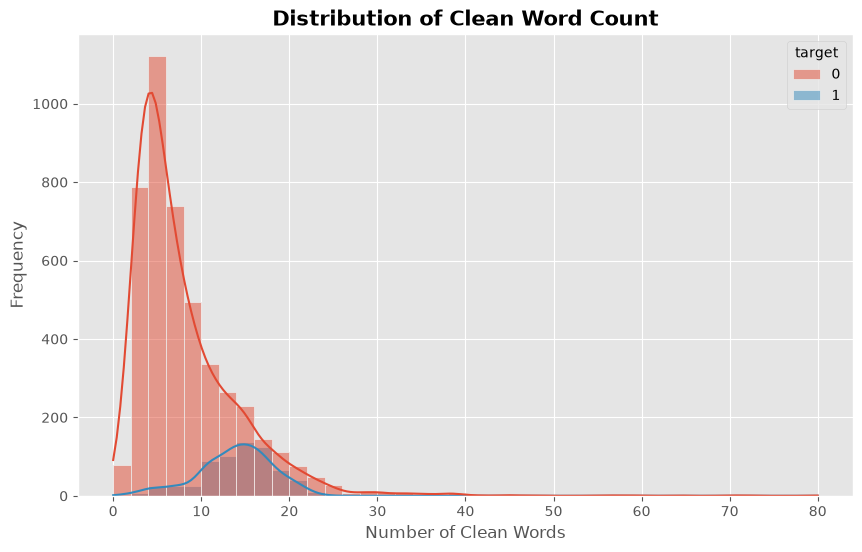

In [46]:
# ==========================================================
# STEP 37 : CLEAN WORD DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="clean_word_count",
    hue="target",
    bins=40,
    kde=True
)

plt.title(
    "Distribution of Clean Word Count",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Number of Clean Words")

plt.ylabel("Frequency")

plt.show()

In [47]:
# ==========================================================
# STEP 38 : SAVE CLEAN DATASET
# ==========================================================

df.to_csv(
    "clean_spam_dataset.csv",
    index=False
)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


In [48]:
# ==========================================================
# STEP 39 : IMPORT LIBRARIES
# ==========================================================

from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

In [49]:
# ==========================================================
# STEP 40 : VERIFY PREPROCESSED DATA
# ==========================================================

if "transformed_text" not in df.columns:
    raise ValueError(
        "Column 'transformed_text' not found. Complete Part 3 first."
    )

df[["text", "transformed_text"]].head()

,text,transformed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


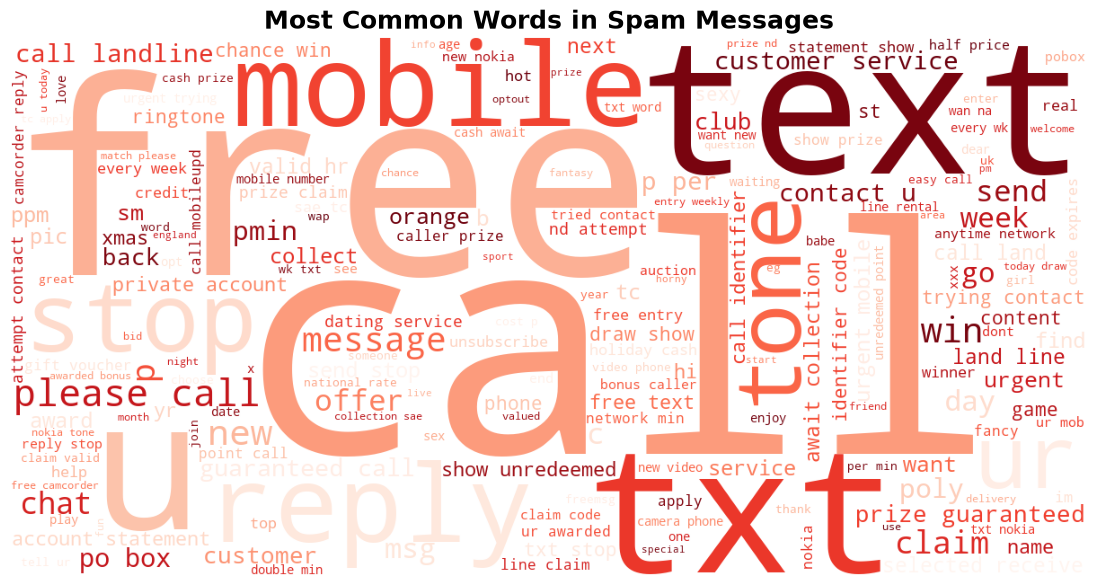

In [50]:
# ==========================================================
# STEP 41 : SPAM WORDCLOUD
# ==========================================================

spam_text = " ".join(
    df[df["target"] == 1]["transformed_text"]
)

spam_wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Reds",
    max_words=200,
    contour_width=1,
    contour_color="black"
).generate(spam_text)

plt.figure(figsize=(15,7))

plt.imshow(spam_wc)

plt.axis("off")

plt.title(
    "Most Common Words in Spam Messages",
    fontsize=18,
    fontweight="bold"
)

plt.show()

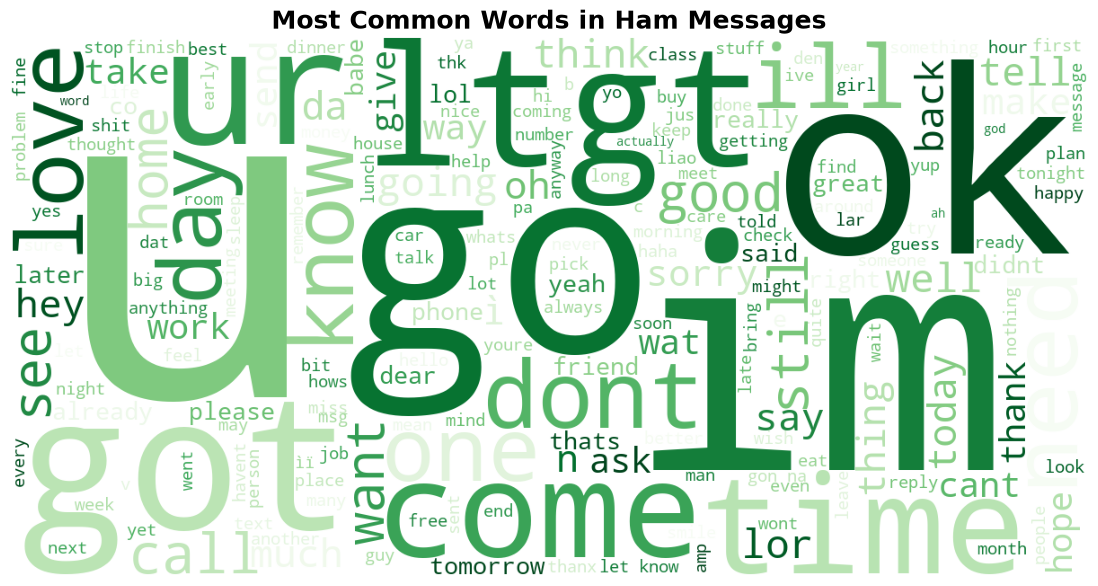

In [51]:
# ==========================================================
# STEP 42 : HAM WORDCLOUD
# ==========================================================

ham_text = " ".join(
    df[df["target"] == 0]["transformed_text"]
)

ham_wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Greens",
    max_words=200,
    contour_width=1,
    contour_color="black"
).generate(ham_text)

plt.figure(figsize=(15,7))

plt.imshow(ham_wc)

plt.axis("off")

plt.title(
    "Most Common Words in Ham Messages",
    fontsize=18,
    fontweight="bold"
)

plt.show()

In [52]:
# ==========================================================
# STEP 43 : CREATE SPAM CORPUS
# ==========================================================

spam_corpus = []

for message in df[df["target"] == 1]["transformed_text"]:

    spam_corpus.extend(message.split())

print("Total Spam Words :", len(spam_corpus))

Total Spam Words : 9066


In [53]:
# ==========================================================
# STEP 44 : TOP 30 SPAM WORDS
# ==========================================================

spam_counter = Counter(spam_corpus)

spam_df = pd.DataFrame(
    spam_counter.most_common(30),
    columns=["Word", "Frequency"]
)

spam_df

,Word,Frequency
0,call,316
1,free,190
2,u,137
3,txt,126
4,text,121
5,ur,119
6,mobile,115
7,stop,106
8,claim,98
9,reply,95


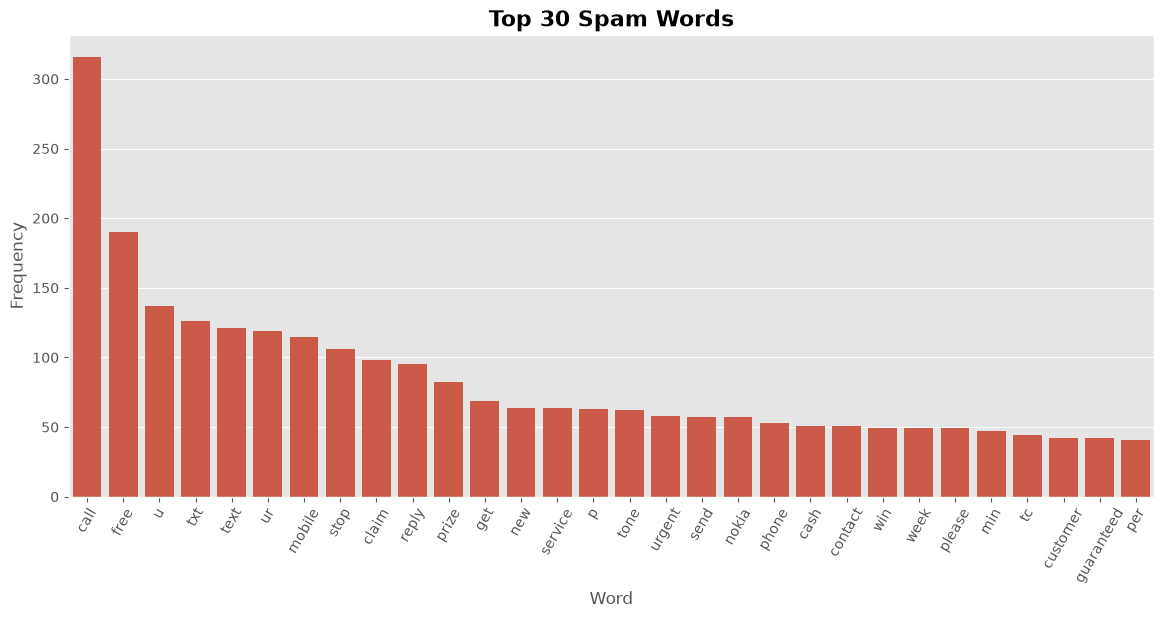

In [54]:
# ==========================================================
# STEP 45 : SPAM WORD FREQUENCY
# ==========================================================

plt.figure(figsize=(14,6))

sns.barplot(
    data=spam_df,
    x="Word",
    y="Frequency"
)

plt.xticks(rotation=60)

plt.title(
    "Top 30 Spam Words",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [55]:
# ==========================================================
# STEP 46 : CREATE HAM CORPUS
# ==========================================================

ham_corpus = []

for message in df[df["target"] == 0]["transformed_text"]:

    ham_corpus.extend(message.split())

print("Total Ham Words :", len(ham_corpus))

Total Ham Words : 36187


In [56]:
# ==========================================================
# STEP 47 : TOP HAM WORDS
# ==========================================================

ham_counter = Counter(ham_corpus)

ham_df = pd.DataFrame(
    ham_counter.most_common(30),
    columns=["Word", "Frequency"]
)

ham_df

,Word,Frequency
0,u,941
1,im,436
2,get,308
3,go,267
4,ltgt,254
5,ok,246
6,dont,242
7,got,238
8,know,229
9,come,223


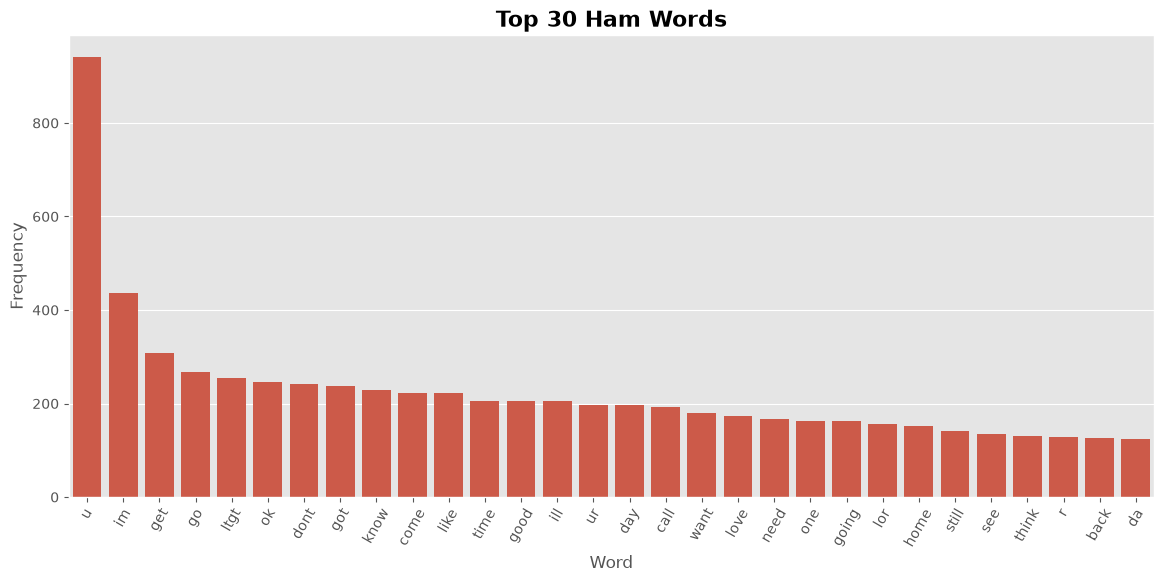

In [57]:
# ==========================================================
# STEP 48 : HAM WORD FREQUENCY
# ==========================================================

plt.figure(figsize=(14,6))

sns.barplot(
    data=ham_df,
    x="Word",
    y="Frequency"
)

plt.xticks(rotation=60)

plt.title(
    "Top 30 Ham Words",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [58]:
# ==========================================================
# STEP 49 : SPAM BIGRAMS
# ==========================================================

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    max_features=20
)

spam_bigram_matrix = vectorizer.fit_transform(
    df[df["target"] == 1]["transformed_text"]
)

spam_bigram_counts = np.asarray(
    spam_bigram_matrix.sum(axis=0)
).flatten()

spam_bigram_df = pd.DataFrame({
    "Bigram": vectorizer.get_feature_names_out(),
    "Count": spam_bigram_counts
}).sort_values(
    by="Count",
    ascending=False
)

spam_bigram_df

,Bigram,Count
11,please call,41
12,po box,23
5,call landline,22
7,customer service,22
9,guaranteed call,21
13,prize guaranteed,20
18,urgent mobile,17
15,send stop,17
10,land line,16
14,selected receive,16


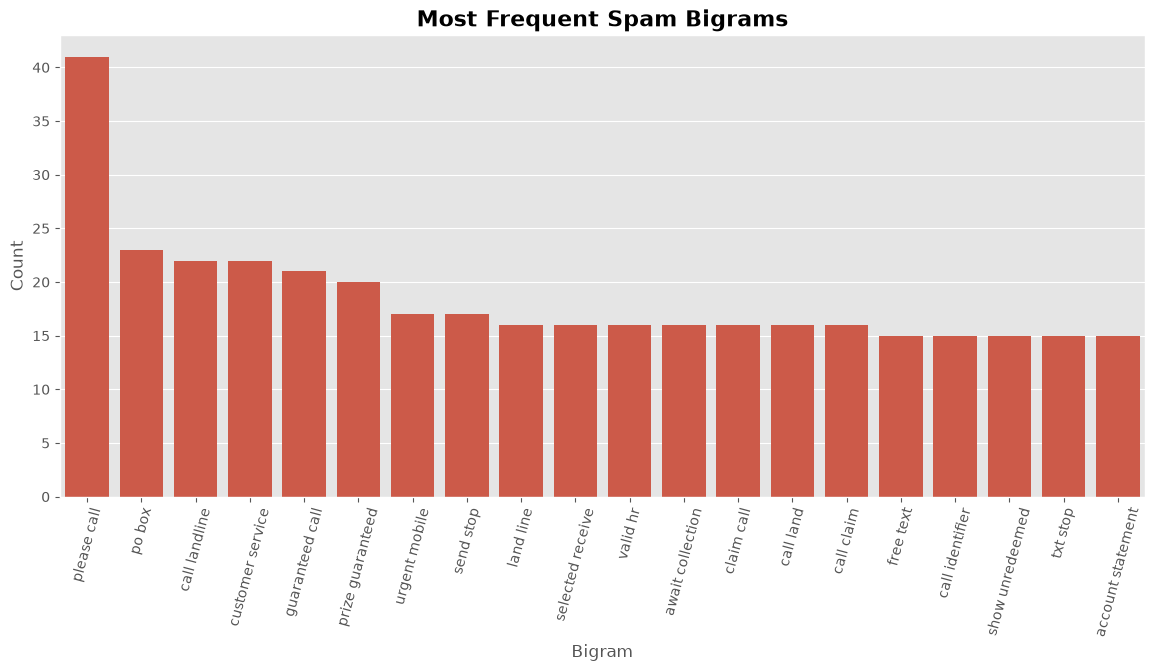

In [59]:
# ==========================================================
# STEP 50 : BIGRAM CHART
# ==========================================================

plt.figure(figsize=(14,6))

sns.barplot(
    data=spam_bigram_df,
    x="Bigram",
    y="Count"
)

plt.xticks(rotation=75)

plt.title(
    "Most Frequent Spam Bigrams",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [60]:
# ==========================================================
# STEP 51 : SPAM TRIGRAMS
# ==========================================================

vectorizer = CountVectorizer(
    ngram_range=(3,3),
    max_features=20
)

spam_trigram_matrix = vectorizer.fit_transform(
    df[df["target"] == 1]["transformed_text"]
)

spam_trigram_counts = np.asarray(
    spam_trigram_matrix.sum(axis=0)
).flatten()

spam_trigram_df = pd.DataFrame({
    "Trigram": vectorizer.get_feature_names_out(),
    "Count": spam_trigram_counts
}).sort_values(
    by="Count",
    ascending=False
)

spam_trigram_df

,Trigram,Count
16,prize guaranteed call,19
5,call land line,16
15,private account statement,15
4,call identifier code,14
0,account statement show,13
9,draw show prize,13
17,show prize guaranteed,13
12,identifier code expires,13
10,guaranteed call land,13
19,statement show unredeemed,13


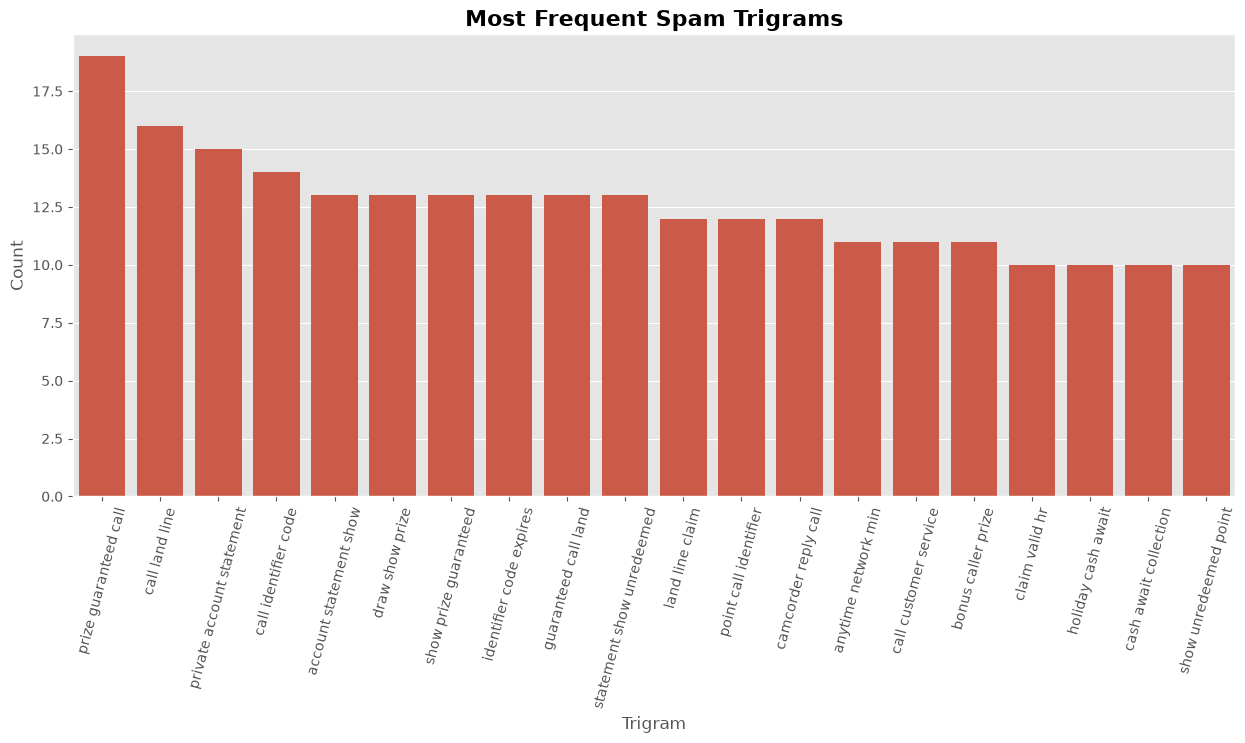

In [61]:
# ==========================================================
# STEP 52 : TRIGRAM CHART
# ==========================================================

plt.figure(figsize=(15,6))

sns.barplot(
    data=spam_trigram_df,
    x="Trigram",
    y="Count"
)

plt.xticks(rotation=75)

plt.title(
    "Most Frequent Spam Trigrams",
    fontsize=16,
    fontweight="bold"
)

plt.show()

In [62]:
# ==========================================================
# STEP 53 : CORPUS COMPARISON
# ==========================================================

comparison_df = pd.DataFrame({
    "Category": ["Ham", "Spam"],
    "Total Words": [
        len(ham_corpus),
        len(spam_corpus)
    ]
})

comparison_df

,Category,Total Words
0,Ham,36187
1,Spam,9066


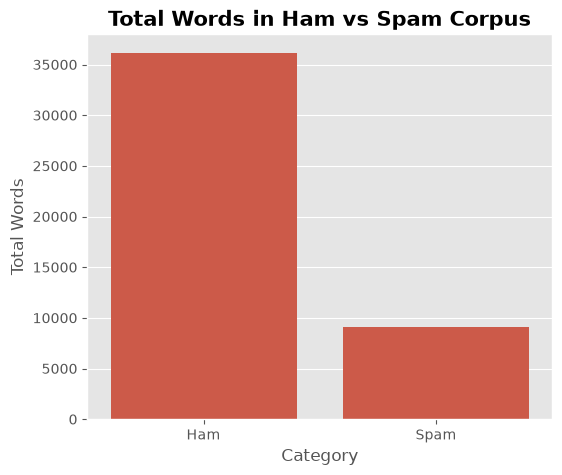

In [63]:
# ==========================================================
# STEP 54 : HAM VS SPAM WORD COUNT
# ==========================================================

plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison_df,
    x="Category",
    y="Total Words"
)

plt.title(
    "Total Words in Ham vs Spam Corpus",
    fontsize=15,
    fontweight="bold"
)

plt.show()

# Text Analysis Insights

### Spam Messages
- Frequently contain promotional words.
- Often include action-oriented terms.
- Many words relate to prizes, money, free offers, and urgency.

### Ham Messages
- Mostly contain conversational language.
- Common everyday vocabulary.
- More natural communication patterns.

### N-Gram Analysis
- Bigrams reveal common word pairs.
- Trigrams capture common short phrases.
- These patterns help explain why TF-IDF with bigrams often improves spam detection performance.

In [64]:
# ==========================================================
# STEP 56 : IMPORT MACHINE LEARNING LIBRARIES
# ==========================================================

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import Pipeline

## 4. Model Building

In [65]:
# ==========================================================
# STEP 57 : DEFINE FEATURES AND TARGET
# ==========================================================

# Input Feature
X = df["transformed_text"]

# Target Variable
y = df["target"]

print("Total Samples :", len(X))

print("Spam Messages :", y.sum())

print("Ham Messages :", len(y) - y.sum())

Total Samples : 5169
Spam Messages : 653
Ham Messages : 4516


In [66]:
# ==========================================================
# STEP 58 : TRAIN TEST SPLIT
# ==========================================================

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
    shuffle=True
)

print("=" * 50)

print("Training Samples :", len(X_train_text))

print("Testing Samples  :", len(X_test_text))

Training Samples : 4135
Testing Samples  : 1034


In [67]:
# ==========================================================
# STEP 59 : VERIFY CLASS DISTRIBUTION
# ==========================================================

train_distribution = y_train.value_counts(normalize=True)

test_distribution = y_test.value_counts(normalize=True)

print("Training Distribution")

print(train_distribution)

print()

print("Testing Distribution")

print(test_distribution)

Training Distribution
target
0    0.873761
1    0.126239
Name: proportion, dtype: float64

Testing Distribution
target
0    0.873308
1    0.126692
Name: proportion, dtype: float64


In [68]:
# ==========================================================
# STEP 60 : CREATE TF-IDF VECTORIZER
# ==========================================================

tfidf = TfidfVectorizer(

    lowercase=True,

    stop_words="english",

    max_features=5000,

    min_df=2,

    max_df=0.95,

    ngram_range=(1,2),

    sublinear_tf=True

)

In [69]:
# ==========================================================
# STEP 61 : FIT TF-IDF
# ==========================================================

X_train = tfidf.fit_transform(X_train_text)

X_test = tfidf.transform(X_test_text)

print("Training Shape :", X_train.shape)

print("Testing Shape  :", X_test.shape)

Training Shape : (4135, 4797)
Testing Shape  : (1034, 4797)


In [70]:
tfidf.fit_transform(X_train_text)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 31621 stored elements and shape (4135, 4797)>

In [71]:
# ==========================================================
# STEP 62 : VOCABULARY SIZE
# ==========================================================

print("Vocabulary Size")

print(len(tfidf.vocabulary_))

Vocabulary Size
4797


In [72]:
# ==========================================================
# STEP 63 : SAMPLE FEATURES
# ==========================================================

feature_names = tfidf.get_feature_names_out()

print(feature_names[:100])

['aah' 'abi' 'ability' 'abiola' 'able' 'able come' 'able deliver'
 'able pay' 'abt' 'abt tht' 'abt ur' 'aburo' 'aburo enjoy' 'ac' 'acc'
 'accept' 'access' 'access number' 'accident' 'accident claim'
 'accidentally' 'accidentally deleted' 'account' 'account ltgt'
 'account number' 'account statement' 'ache' 'aclpm' 'action'
 'action tscs' 'activate' 'activity' 'actual' 'actually' 'actually im'
 'actually send' 'ad' 'add' 'added' 'added contact' 'addie' 'address'
 'admin' 'admirer' 'admirer looking' 'adoring' 'adoring kiss' 'adult'
 'advance' 'advice' 'advise' 'advise following' 'ae' 'affair'
 'affectionate' 'afraid' 'aft' 'aft ur' 'afternoon' 'afternoon boytoy'
 'afternoon love' 'aftr' 'age' 'ago' 'ah' 'ah confuses' 'aha' 'ahead'
 'ahead month' 'ahmad' 'aight' 'aight ill' 'aint' 'air' 'airport' 'airtel'
 'aiya' 'aiyah' 'aiyah ok' 'aiyar' 'aiyo' 'al' 'al hallaq' 'album'
 'alcohol' 'alcohol jay' 'alert' 'alex' 'alex nichols' 'alfie'
 'alfie moon' 'alive' 'allah' 'allow' 'allowed' 'alright

In [73]:
# ==========================================================
# STEP 64 : MOST IMPORTANT FEATURES
# ==========================================================

feature_df = pd.DataFrame({

    "Feature": feature_names

})

feature_df.head(20)

,Feature
0,aah
1,abi
2,ability
3,abiola
4,able
5,able come
6,able deliver
7,able pay
8,abt
9,abt tht


In [74]:
# ==========================================================
# STEP 65 : SPARSITY INFORMATION
# ==========================================================

print("Training Matrix")

print(X_train)

print()

print("Testing Matrix")

print(X_test)

Training Matrix
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 31621 stored elements and shape (4135, 4797)>
  Coords	Values
  (0, 735)	0.6413734325348693
  (0, 661)	0.46236272213773155
  (0, 1638)	0.6122587959481073
  (1, 1791)	0.5210220999992472
  (1, 2115)	0.44845942096703073
  (1, 1296)	0.5489660344725342
  (1, 943)	0.4754539010816827
  (2, 4)	0.40568888063136954
  (2, 2053)	0.8245213510720855
  (2, 4478)	0.27971296294097914
  (2, 846)	0.2781038153659667
  (3, 661)	0.19093160186379804
  (3, 1747)	0.22756321368777682
  (3, 4318)	0.17766223015334517
  (3, 1648)	0.29498169388900647
  (3, 980)	0.2774641972222085
  (3, 1798)	0.2923854539804402
  (3, 4526)	0.23135055917595296
  (3, 3799)	0.31908380151357985
  (3, 4163)	0.2478343917818149
  (3, 3399)	0.32921939056059885
  (3, 2193)	0.18907739205983937
  (3, 1757)	0.3737704527592241
  (3, 671)	0.36070340580495114
  (4, 1427)	1.0
  :	:
  (4132, 1214)	0.2205843258672518
  (4132, 2391)	0.19397601327836125
  (4132, 2304)	0.30733

In [75]:
# ==========================================================
# STEP 66 : DENSE MATRICES
# ==========================================================

X_train_dense = X_train.toarray()

X_test_dense = X_test.toarray()

In [76]:
# ==========================================================
# STEP 67 : SAVE TF-IDF VECTORIZER
# ==========================================================

import pickle

with open("vectorizer.pkl", "wb") as file:

    pickle.dump(tfidf, file)

print("Vectorizer Saved Successfully")

Vectorizer Saved Successfully


In [77]:
# ==========================================================
# STEP 68 : VERIFY SAVED VECTORIZER
# ==========================================================

with open("vectorizer.pkl", "rb") as file:

    loaded_vectorizer = pickle.load(file)

print(type(loaded_vectorizer))

print("Vectorizer Loaded Successfully")

<class 'sklearn.feature_extraction.text.TfidfVectorizer'>
Vectorizer Loaded Successfully


In [78]:
# ==========================================================
# STEP 69 : TEST VECTORIZER
# ==========================================================

sample_message = [

    "Congratulations! You have won a free iPhone. Click now."

]

sample_vector = loaded_vectorizer.transform(sample_message)

print(sample_vector.shape)

(1, 4797)


In [79]:
# ==========================================================
# STEP 70 : PIPELINE PREVIEW
# ==========================================================

pipeline = Pipeline([

    ("tfidf", tfidf)

])

print(pipeline)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=5000, min_df=2,
                                 ngram_range=(1, 2), stop_words='english',
                                 sublinear_tf=True))])


In [80]:
# ==========================================================
# STEP 71 : IMPORT CLASSIFIERS
# ==========================================================

from sklearn.naive_bayes import (
    GaussianNB,
    MultinomialNB,
    BernoulliNB
)

from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

In [81]:
# ==========================================================
# STEP 72 : IMPORT METRICS
# ==========================================================

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    confusion_matrix,

    classification_report

)

import time

In [82]:
# ==========================================================
# STEP 73 : INITIALIZE MODELS
# ==========================================================

models = {

    "Gaussian NB": GaussianNB(),

    "Multinomial NB": MultinomialNB(),

    "Bernoulli NB": BernoulliNB(),

    "Logistic Regression": LogisticRegression(
        solver="liblinear",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(
        kernel="linear",
        probability=True,
        random_state=42
    )

}

In [83]:
# ==========================================================
# STEP 74 : TRAINING FUNCTION
# ==========================================================

def evaluate_model(model, model_name):

    # GaussianNB requires dense matrices
    if model_name == "Gaussian NB":

        Xtr = X_train_dense
        Xts = X_test_dense

    else:

        Xtr = X_train
        Xts = X_test

    # -----------------------------
    # Training
    # -----------------------------

    start_train = time.time()

    model.fit(Xtr, y_train)

    end_train = time.time()

    # -----------------------------
    # Prediction
    # -----------------------------

    start_pred = time.time()

    y_pred = model.predict(Xts)

    end_pred = time.time()

    # -----------------------------
    # Probability
    # -----------------------------

    if hasattr(model, "predict_proba"):

        probabilities = model.predict_proba(Xts)[:,1]

        roc_auc = roc_auc_score(
            y_test,
            probabilities
        )

    else:

        roc_auc = np.nan

    results = {

        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "Precision": precision_score(
            y_test,
            y_pred
        ),

        "Recall": recall_score(
            y_test,
            y_pred
        ),

        "F1 Score": f1_score(
            y_test,
            y_pred
        ),

        "ROC AUC": roc_auc,

        "Training Time": end_train-start_train,

        "Prediction Time": end_pred-start_pred

    }

    return results

In [84]:
# ==========================================================
# STEP 75 : TRAIN ALL MODELS
# ==========================================================

results = []

for model_name, model in models.items():

    print(f"Training {model_name}...")

    result = evaluate_model(
        model,
        model_name
    )

    results.append(result)

print()

print("Training Completed.")

Training Gaussian NB...
Training Multinomial NB...
Training Bernoulli NB...
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Training Gradient Boosting...
Training AdaBoost...
Training KNN...
Training SVM...

Training Completed.


In [85]:
# ==========================================================
# STEP 76 : RESULTS TABLE
# ==========================================================

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time,Prediction Time
0,Gaussian NB,0.869439,0.491228,0.854962,0.623955,0.863251,0.110334,0.032672
1,Multinomial NB,0.966151,0.989796,0.740458,0.847162,0.979728,0.024371,0.006318
2,Bernoulli NB,0.963250,0.989474,0.717557,0.831858,0.996331,0.010650,0.002902
3,Logistic Regression,0.954545,0.988372,0.648855,0.783410,0.994040,0.034210,0.005394
4,Decision Tree,0.926499,0.772277,0.595420,0.672414,0.786894,0.026461,0.002944
5,Random Forest,0.967118,0.953271,0.778626,0.857143,0.991584,0.416333,0.037812
6,Extra Trees,0.972921,0.947826,0.832061,0.886179,0.988013,0.602685,0.039159
7,Gradient Boosting,0.950677,0.954545,0.641221,0.767123,0.966968,0.333562,0.008390
8,AdaBoost,0.906190,0.814815,0.335878,0.475676,0.873513,0.097424,0.009793
9,KNN,0.901354,1.000000,0.221374,0.362500,0.778169,0.007411,0.072548


In [86]:
# ==========================================================
# STEP 77 : SORT RESULTS
# ==========================================================

results_df = results_df.sort_values(

    by="F1 Score",

    ascending=False

).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time,Prediction Time
0,SVM,0.981625,0.982759,0.870229,0.923077,0.994488,0.915384,0.037052
1,Extra Trees,0.972921,0.947826,0.832061,0.886179,0.988013,0.602685,0.039159
2,Random Forest,0.967118,0.953271,0.778626,0.857143,0.991584,0.416333,0.037812
3,Multinomial NB,0.966151,0.989796,0.740458,0.847162,0.979728,0.024371,0.006318
4,Bernoulli NB,0.963250,0.989474,0.717557,0.831858,0.996331,0.010650,0.002902
5,Logistic Regression,0.954545,0.988372,0.648855,0.783410,0.994040,0.034210,0.005394
6,Gradient Boosting,0.950677,0.954545,0.641221,0.767123,0.966968,0.333562,0.008390
7,Decision Tree,0.926499,0.772277,0.595420,0.672414,0.786894,0.026461,0.002944
8,Gaussian NB,0.869439,0.491228,0.854962,0.623955,0.863251,0.110334,0.032672
9,AdaBoost,0.906190,0.814815,0.335878,0.475676,0.873513,0.097424,0.009793


In [87]:
# ==========================================================
# STEP 78 : BEST MODEL
# ==========================================================

best_model = results_df.iloc[0]

print(best_model)

Model                   SVM
Accuracy           0.981625
Precision          0.982759
Recall             0.870229
F1 Score           0.923077
ROC AUC            0.994488
Training Time      0.915384
Prediction Time    0.037052
Name: 0, dtype: object


In [88]:
# ==========================================================
# STEP 79 : SAVE RESULTS
# ==========================================================

results_df.to_csv(

    "model_comparison.csv",

    index=False

)

print("Results Saved Successfully")

Results Saved Successfully


In [89]:
# ==========================================================
# STEP 80 : TOP MODELS
# ==========================================================

results_df.head()

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time,Prediction Time
0,SVM,0.981625,0.982759,0.870229,0.923077,0.994488,0.915384,0.037052
1,Extra Trees,0.972921,0.947826,0.832061,0.886179,0.988013,0.602685,0.039159
2,Random Forest,0.967118,0.953271,0.778626,0.857143,0.991584,0.416333,0.037812
3,Multinomial NB,0.966151,0.989796,0.740458,0.847162,0.979728,0.024371,0.006318
4,Bernoulli NB,0.963250,0.989474,0.717557,0.831858,0.996331,0.010650,0.002902


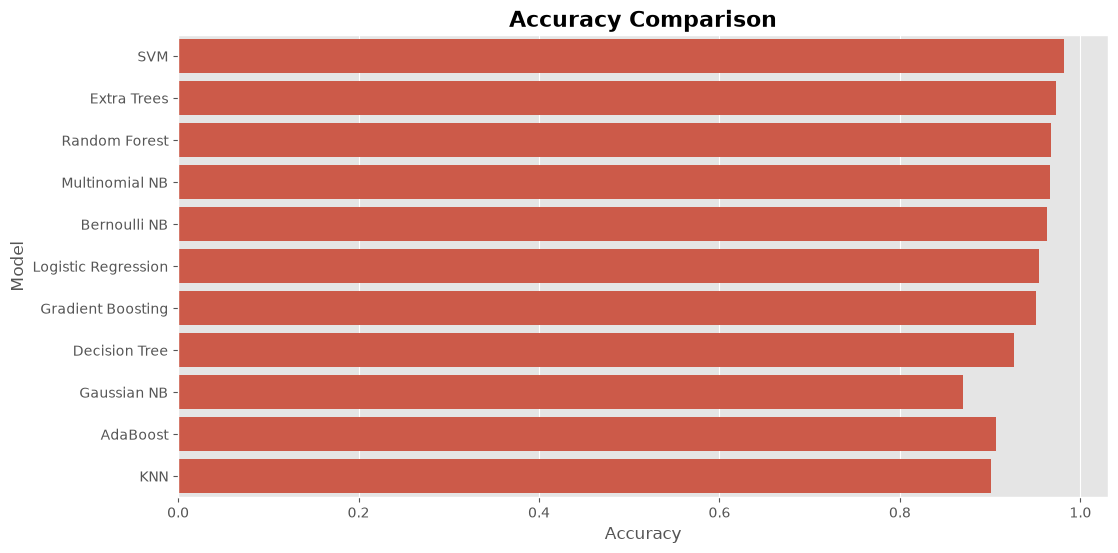

In [90]:
# ==========================================================
# STEP 81 : ACCURACY COMPARISON
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(

    data=results_df,

    x="Accuracy",

    y="Model"

)

plt.title(

    "Accuracy Comparison",

    fontsize=16,

    fontweight="bold"

)

plt.show()

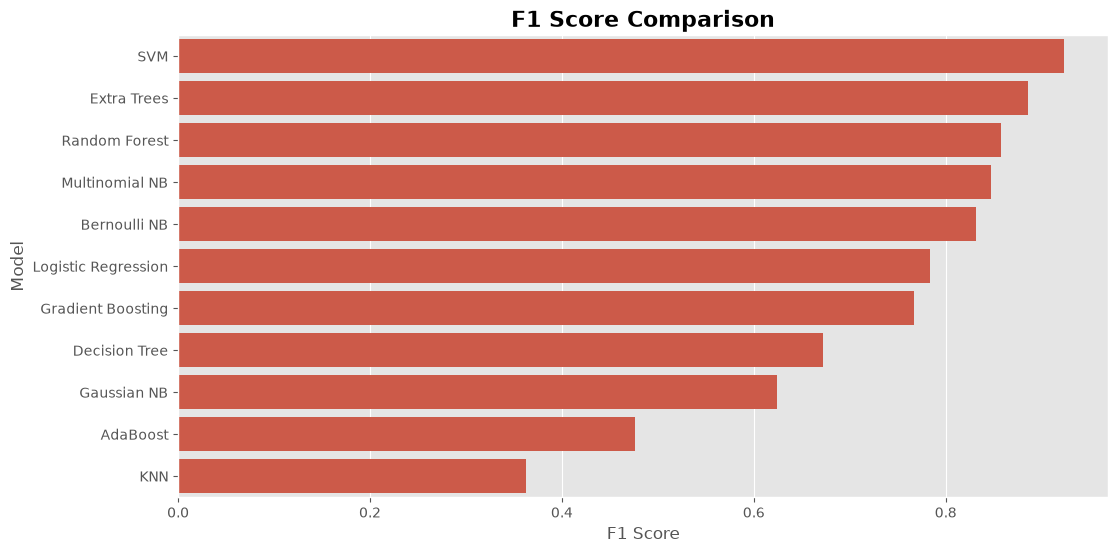

In [91]:
# ==========================================================
# STEP 82 : F1 SCORE COMPARISON
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(

    data=results_df,

    x="F1 Score",

    y="Model"

)

plt.title(

    "F1 Score Comparison",

    fontsize=16,

    fontweight="bold"

)

plt.show()

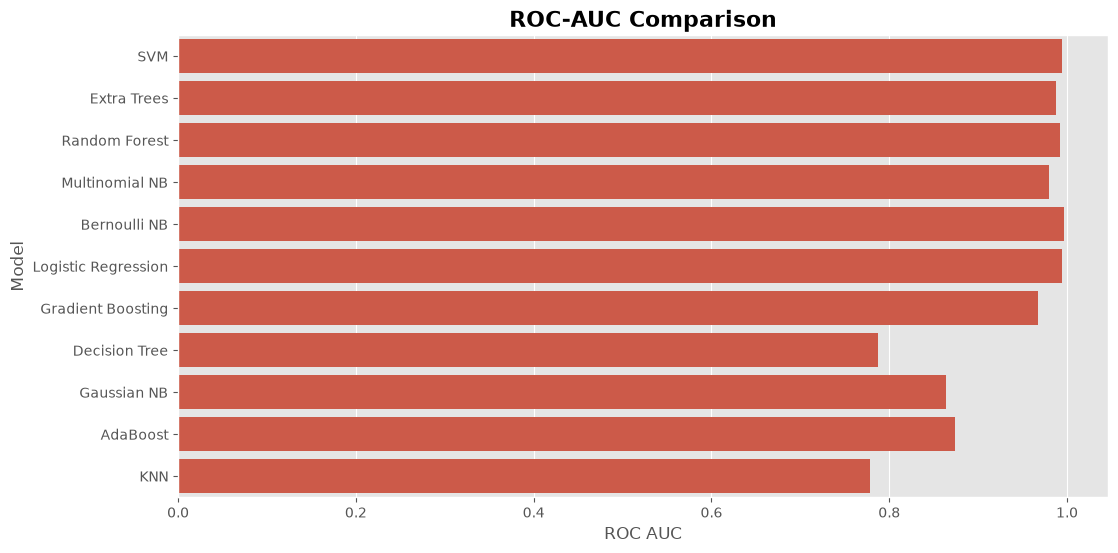

In [92]:
# ==========================================================
# STEP 83 : ROC-AUC COMPARISON
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(

    data=results_df,

    x="ROC AUC",

    y="Model"

)

plt.title(

    "ROC-AUC Comparison",

    fontsize=16,

    fontweight="bold"

)

plt.show()

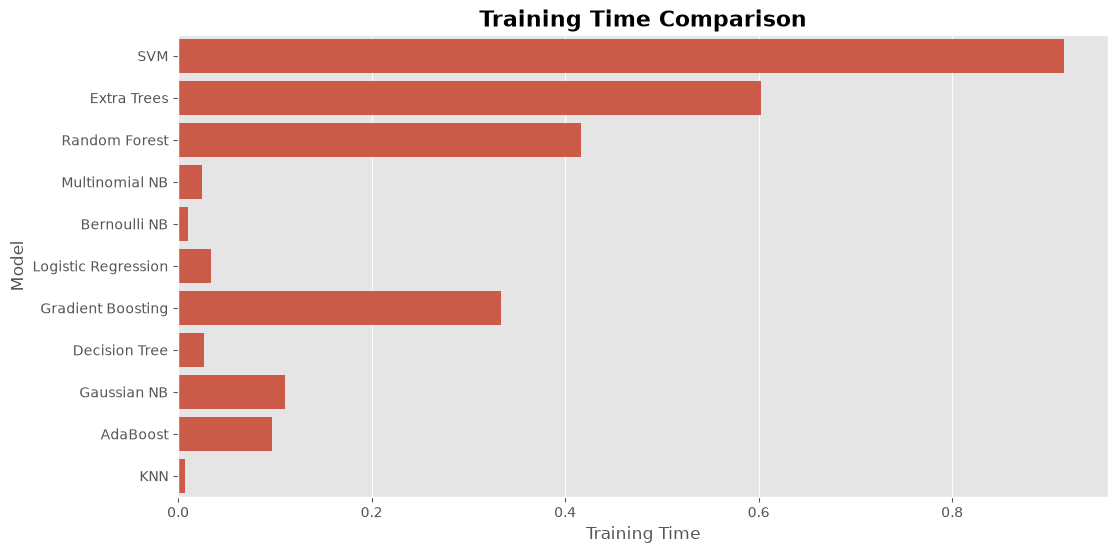

In [93]:
# ==========================================================
# STEP 84 : TRAINING TIME
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(

    data=results_df,

    x="Training Time",

    y="Model"

)

plt.title(

    "Training Time Comparison",

    fontsize=16,

    fontweight="bold"

)

plt.show()

In [94]:
# ==========================================================
# STEP 85 : FINAL RANKING
# ==========================================================

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time,Prediction Time
0,SVM,0.981625,0.982759,0.870229,0.923077,0.994488,0.915384,0.037052
1,Extra Trees,0.972921,0.947826,0.832061,0.886179,0.988013,0.602685,0.039159
2,Random Forest,0.967118,0.953271,0.778626,0.857143,0.991584,0.416333,0.037812
3,Multinomial NB,0.966151,0.989796,0.740458,0.847162,0.979728,0.024371,0.006318
4,Bernoulli NB,0.963250,0.989474,0.717557,0.831858,0.996331,0.010650,0.002902
5,Logistic Regression,0.954545,0.988372,0.648855,0.783410,0.994040,0.034210,0.005394
6,Gradient Boosting,0.950677,0.954545,0.641221,0.767123,0.966968,0.333562,0.008390
7,Decision Tree,0.926499,0.772277,0.595420,0.672414,0.786894,0.026461,0.002944
8,Gaussian NB,0.869439,0.491228,0.854962,0.623955,0.863251,0.110334,0.032672
9,AdaBoost,0.906190,0.814815,0.335878,0.475676,0.873513,0.097424,0.009793


In [95]:
# ==========================================================
# STEP 86 : IMPORT GRID SEARCH
# ==========================================================

from sklearn.model_selection import GridSearchCV

In [96]:
# ==========================================================
# STEP 87 : MULTINOMIAL NAIVE BAYES
# ==========================================================

mnb = MultinomialNB()

mnb_parameters = {
    "alpha": [0.01, 0.1, 0.5, 1.0, 2.0]
}

mnb_grid = GridSearchCV(
    estimator=mnb,
    param_grid=mnb_parameters,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

mnb_grid.fit(X_train, y_train)

print("Best Parameters")
print(mnb_grid.best_params_)

print("\nBest F1 Score")
print(mnb_grid.best_score_)

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

Best Parameters
{'alpha': 0.1}

Best F1 Score
0.917018422190836


In [97]:
# ==========================================================
# STEP 88 : LOGISTIC REGRESSION
# ==========================================================

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_parameters = {

    "C": [0.01,0.1,1,10],

    "solver": [
        "liblinear",
        "lbfgs"
    ]

}

lr_grid = GridSearchCV(

    estimator=lr,

    param_grid=lr_parameters,

    scoring="f1",

    cv=5,

    n_jobs=-1

)

lr_grid.fit(X_train,y_train)

print(lr_grid.best_params_)

print(lr_grid.best_score_)

{'C': 10, 'solver': 'liblinear'}
0.8843208377221835


In [98]:
# ==========================================================
# STEP 89 : SUPPORT VECTOR MACHINE
# ==========================================================

svc = SVC(
    probability=True,
    random_state=42
)

svc_parameters = {

    "kernel":[
        "linear",
        "rbf"
    ],

    "C":[
        0.1,
        1,
        10
    ]

}

svc_grid = GridSearchCV(

    svc,

    svc_parameters,

    scoring="f1",

    cv=5,

    n_jobs=-1

)

svc_grid.fit(X_train,y_train)

print(svc_grid.best_params_)

print(svc_grid.best_score_)

{'C': 1, 'kernel': 'linear'}
0.8974036447084363


In [99]:
# ==========================================================
# STEP 90 : RANDOM FOREST
# ==========================================================

rf = RandomForestClassifier(
    random_state=42
)

rf_parameters = {

    "n_estimators":[
        100,
        200
    ],

    "max_depth":[
        10,
        20,
        None
    ],

    "min_samples_split":[
        2,
        5
    ]

}

rf_grid = GridSearchCV(

    rf,

    rf_parameters,

    scoring="f1",

    cv=5,

    n_jobs=-1

)

rf_grid.fit(X_train,y_train)

print(rf_grid.best_params_)

print(rf_grid.best_score_)

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
0.8783713525718669


In [100]:
# ==========================================================
# STEP 91 : EXTRA TREES
# ==========================================================

et = ExtraTreesClassifier(
    random_state=42
)

et_parameters = {

    "n_estimators":[
        100,
        200
    ],

    "max_depth":[
        None,
        20,
        40
    ]

}

et_grid = GridSearchCV(

    et,

    et_parameters,

    scoring="f1",

    cv=5,

    n_jobs=-1

)

et_grid.fit(X_train,y_train)

print(et_grid.best_params_)

print(et_grid.best_score_)

{'max_depth': None, 'n_estimators': 100}
0.8857332707489689


In [101]:
# ==========================================================
# STEP 92 : BEST PARAMETERS
# ==========================================================

best_models = pd.DataFrame({

    "Model":[

        "Multinomial NB",

        "Logistic Regression",

        "SVM",

        "Random Forest",

        "Extra Trees"

    ],

    "Best Score":[

        mnb_grid.best_score_,

        lr_grid.best_score_,

        svc_grid.best_score_,

        rf_grid.best_score_,

        et_grid.best_score_

    ]

})

best_models = best_models.sort_values(

    by="Best Score",

    ascending=False

)

best_models

,Model,Best Score
0,Multinomial NB,0.917018
2,SVM,0.897404
4,Extra Trees,0.885733
1,Logistic Regression,0.884321
3,Random Forest,0.878371


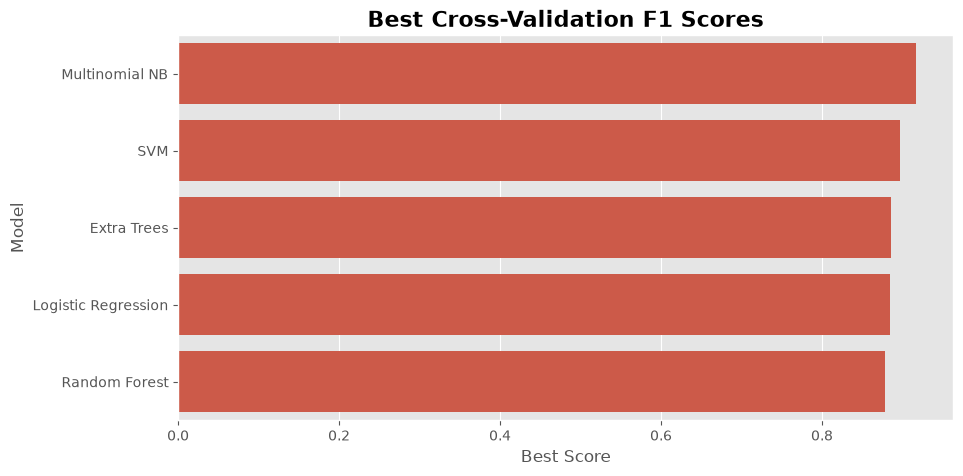

In [102]:
# ==========================================================
# STEP 93 : VISUALIZATION
# ==========================================================

plt.figure(figsize=(10,5))

sns.barplot(

    data=best_models,

    x="Best Score",

    y="Model"

)

plt.title(

    "Best Cross-Validation F1 Scores",

    fontsize=16,

    fontweight="bold"

)

plt.show()

In [103]:
# ==========================================================
# STEP 94 : SAVE BEST ESTIMATORS
# ==========================================================

best_estimators = {

    "Multinomial NB": mnb_grid.best_estimator_,

    "Logistic Regression": lr_grid.best_estimator_,

    "SVM": svc_grid.best_estimator_,

    "Random Forest": rf_grid.best_estimator_,

    "Extra Trees": et_grid.best_estimator_

}

print(best_estimators.keys())

dict_keys(['Multinomial NB', 'Logistic Regression', 'SVM', 'Random Forest', 'Extra Trees'])


In [104]:
# ==========================================================
# STEP 95 : TEST SET EVALUATION
# ==========================================================

tuned_results = []

for name, model in best_estimators.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    tuned_results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, predictions),

        "Precision": precision_score(y_test, predictions),

        "Recall": recall_score(y_test, predictions),

        "F1 Score": f1_score(y_test, predictions)

    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
2,SVM,0.981625,0.982759,0.870229,0.923077
0,Multinomial NB,0.977756,0.973684,0.847328,0.906122
1,Logistic Regression,0.977756,0.973684,0.847328,0.906122
4,Extra Trees,0.972921,0.947826,0.832061,0.886179
3,Random Forest,0.968085,0.937500,0.801527,0.864198


In [105]:
# ==========================================================
# STEP 96 : IMPORT EVALUATION LIBRARIES
# ==========================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
# ==========================================================
# STEP 97 : SELECT BEST MODEL
# ==========================================================

best_model_name = tuned_results_df.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]["Model"]

best_model = best_estimators[best_model_name]

print("Best Model :", best_model_name)

Best Model : SVM


In [107]:
# ==========================================================
# STEP 98 : TRAIN BEST MODEL
# ==========================================================

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

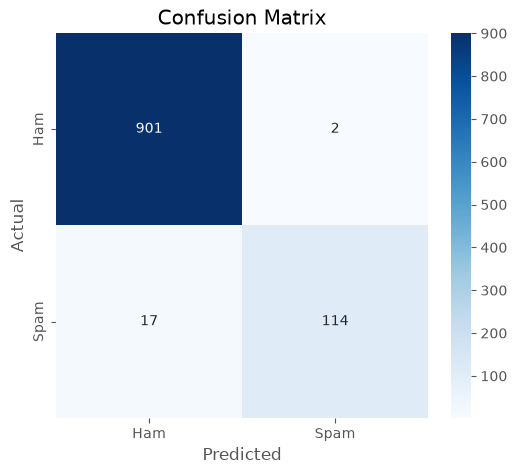

In [108]:
# ==========================================================
# STEP 99 : CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham","Spam"],
    yticklabels=["Ham","Spam"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [109]:
# ==========================================================
# STEP 100 : CLASSIFICATION REPORT
# ==========================================================

print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham","Spam"]
))

              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.98      0.87      0.92       131

    accuracy                           0.98      1034
   macro avg       0.98      0.93      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [110]:
# ==========================================================
# STEP 101 : CROSS VALIDATION
# ==========================================================

scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print("Fold Scores")

print(scores)

print()

print("Average")

print(scores.mean())

Fold Scores
[0.87096774 0.89690722 0.89005236 0.90909091 0.92      ]

Average
0.8974036447084363


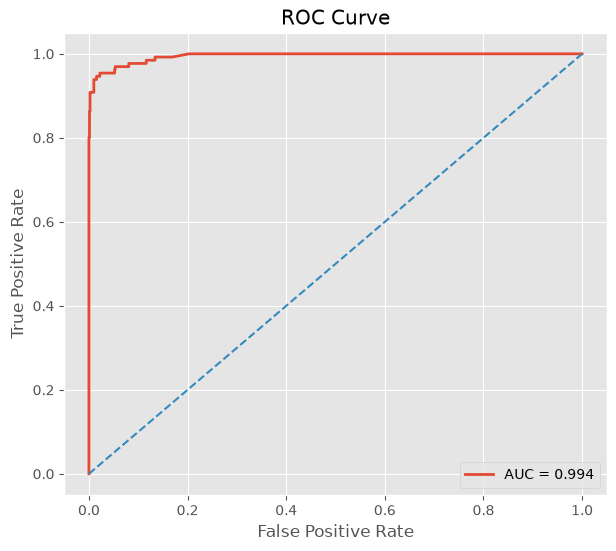

In [111]:
# ==========================================================
# STEP 102 : ROC CURVE
# ==========================================================

if hasattr(best_model, "predict_proba"):

    probs = best_model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, probs)

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7,6))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {roc_auc:.3f}",
        linewidth=2
    )

    plt.plot([0,1],[0,1],"--")

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.legend()

    plt.show()

else:

    print("ROC curve skipped because the selected model does not provide probabilities.")

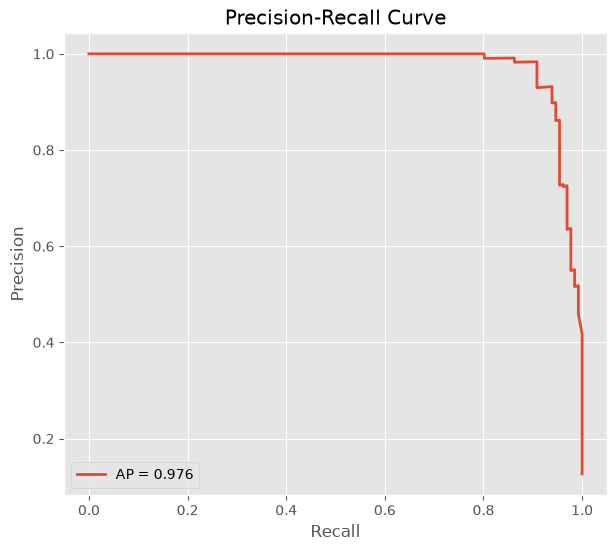

In [112]:
# ==========================================================
# STEP 103 : PRECISION-RECALL CURVE
# ==========================================================

if hasattr(best_model, "predict_proba"):

    precision, recall, _ = precision_recall_curve(
        y_test,
        probs
    )

    ap = average_precision_score(
        y_test,
        probs
    )

    plt.figure(figsize=(7,6))

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"AP = {ap:.3f}"
    )

    plt.xlabel("Recall")

    plt.ylabel("Precision")

    plt.title("Precision-Recall Curve")

    plt.legend()

    plt.show()

In [113]:
# ==========================================================
# STEP 104 : MISCLASSIFIED EXAMPLES
# ==========================================================

errors = pd.DataFrame({
    "Message": X_test_text.reset_index(drop=True),
    "Actual": y_test.reset_index(drop=True),
    "Predicted": pd.Series(y_pred)
})

misclassified = errors[
    errors["Actual"] != errors["Predicted"]
]

print(f"Total Misclassified: {len(misclassified)}")

misclassified.head(20)

Total Misclassified: 19


,Message,Actual,Predicted
112,send logo ur lover name joined heart txt love ...,1,0
125,congrats year special cinema pas call c suprma...,1,0
160,hi babe jordan r u im home abroad lonely text ...,1,0
168,hi ur lookin saucy daytime fun wiv busty marri...,1,0
230,asked mobile chatlines inclu free min india cu...,1,0
277,ok ur typical reply,0,1
308,hi lucy hubby meetins day fri b alone hotel u ...,1,0
326,missed call alert number called left message,1,0
327,k k sm chat,0,1
404,freemsg hey u got videopic fones reply wild tx...,1,0


In [114]:
# ==========================================================
# STEP 106 : IMPORT LIBRARIES
# ==========================================================

import pickle
import json
import sklearn

from datetime import datetime

from sklearn.pipeline import Pipeline

In [115]:
# ==========================================================
# STEP 107 : FINAL MODEL
# ==========================================================

# Example:
# Replace with the actual best estimator after tuning

final_model = best_estimators[best_model_name]

print(type(final_model))

<class 'sklearn.svm._classes.SVC'>


In [116]:
# ==========================================================
# STEP 108 : COMPLETE PIPELINE
# ==========================================================

spam_pipeline = Pipeline([

    ("tfidf", TfidfVectorizer(

        lowercase=False,

        stop_words=None,

        max_features=5000,

        min_df=2,

        max_df=0.95,

        ngram_range=(1,2),

        sublinear_tf=True

    )),

    ("classifier", final_model)

])

spam_pipeline.fit(
    X_train_text,
    y_train
)

print("Pipeline Ready")

Pipeline Ready


In [117]:
# ==========================================================
# STEP 109 : SAVE PIPELINE
# ==========================================================

with open(
    "spam_detector_pipeline.pkl",
    "wb"
) as file:

    pickle.dump(
        spam_pipeline,
        file
    )

print("Pipeline Saved")

Pipeline Saved


In [118]:
# ==========================================================
# STEP 111 : MODEL METADATA
# ==========================================================

metadata = {

    "project": "SMS Spam Detection",

    "algorithm": best_model_name,

    "dataset": "SMS Spam Collection",

    "created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

    "scikit_learn": sklearn.__version__,

    "train_samples": X_train.shape[0],

    "test_samples": X_test.shape[0]

}

with open(
    "model_metadata.json",
    "w"
) as file:

    json.dump(
        metadata,
        file,
        indent=4
    )

print(metadata)

{'project': 'SMS Spam Detection', 'algorithm': 'SVM', 'dataset': 'SMS Spam Collection', 'created': '2026-07-29 16:02:00', 'scikit_learn': '1.9.0', 'train_samples': 4135, 'test_samples': 1034}


In [132]:
import pickle

with open("spam_detector_pipeline.pkl", "wb") as f:
    pickle.dump(spam_pipeline, f)

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [133]:
import pickle

with open("spam_detector_pipeline.pkl", "rb") as f:
    loaded_pipeline = pickle.load(f)

print("Pipeline loaded successfully!")
print(type(loaded_pipeline))

Pipeline loaded successfully!
<class 'sklearn.pipeline.Pipeline'>


In [119]:
import os

print(os.getcwd())          # Current working directory
print(os.listdir())         # Files in the current directory

/Users/amangadhiya/Downloads/Sms-spam-classifier
['model_comparison.csv', 'model_metadata.json', 'requirements.txt', 'sms-spam-detection.ipynb', 'spam_detector_pipeline.pkl', 'app.py', 'vectorizer.pkl', 'clean_spam_dataset.csv', 'spam.csv']


In [134]:
print("spam_pipeline exists:", "spam_pipeline" in globals())
print("loaded_pipeline exists:", "loaded_pipeline" in globals())

spam_pipeline exists: True
loaded_pipeline exists: True


In [136]:
# ==========================================================
# STEP 112 : SINGLE PREDICTION
# ==========================================================

message = [

    "Congratulations! You won a free iPhone."

]

prediction = loaded_pipeline.predict(message)

print(prediction)

[1]


In [137]:
# ==========================================================
# STEP 113 : LABEL OUTPUT
# ==========================================================

label = "Spam" if prediction[0] == 1 else "Ham"

print("Prediction:", label)

Prediction: Spam


In [138]:
# ==========================================================
# STEP 114 : CONFIDENCE SCORE
# ==========================================================

if hasattr(
    loaded_pipeline.named_steps["classifier"],
    "predict_proba"
):

    probabilities = loaded_pipeline.predict_proba(message)

    print(probabilities)

[[0.02031684 0.97968316]]


In [139]:
# ==========================================================
# STEP 115 : MULTIPLE MESSAGES
# ==========================================================

messages = [

    "Win cash now",

    "Meeting at 5 PM",

    "Congratulations, claim your prize",

    "Let's have lunch tomorrow"

]

predictions = loaded_pipeline.predict(messages)

for msg, pred in zip(messages, predictions):

    label = "Spam" if pred else "Ham"

    print(f"{label} --> {msg}")

Ham --> Win cash now
Ham --> Meeting at 5 PM
Spam --> Congratulations, claim your prize
Ham --> Let's have lunch tomorrow


In [146]:
# ==========================================================
# STEP 116 : CUSTOM FUNCTION
# ==========================================================

def predict_sms(message):

    prediction = loaded_pipeline.predict([message])[0]

    if prediction == 1:

        return "Spam"

    return "Ham"

In [147]:
# ==========================================================
# STEP 117 : TEST FUNCTION
# ==========================================================

print(

    predict_sms(

        "Free vacation waiting for you."

    )

)

Ham


In [148]:
# ==========================================================
# STEP 118 : VERIFY PIPELINE
# ==========================================================

pipeline_predictions = loaded_pipeline.predict(
    X_test_text
)

print(

    accuracy_score(
        y_test,
        pipeline_predictions
    )

)

0.9806576402321083


In [149]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (4135, 4797)
X_test shape : (1034, 4797)


In [150]:
print("Model expects:", final_model.n_features_in_)

Model expects: 5000


In [151]:
# ==========================================================
# STEP 119 : VERIFY FINAL PIPELINE
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

pipeline_predictions = spam_pipeline.predict(X_test_text)

print("=" * 50)
print("FINAL PIPELINE PERFORMANCE")
print("=" * 50)

print(f"Accuracy : {accuracy_score(y_test, pipeline_predictions):.4f}")
print(f"Precision: {precision_score(y_test, pipeline_predictions):.4f}")
print(f"Recall   : {recall_score(y_test, pipeline_predictions):.4f}")
print(f"F1 Score : {f1_score(y_test, pipeline_predictions):.4f}")

FINAL PIPELINE PERFORMANCE
Accuracy : 0.9807
Precision: 0.9744
Recall   : 0.8702
F1 Score : 0.9194


In [154]:
print(best_model_name)
print(type(classifier))
print(classifier)
print(classifier.coef_.shape)
coefficients = classifier.coef_

print(type(coefficients))
print(coefficients.shape)

SVM
<class 'sklearn.svm._classes.SVC'>
SVC(C=1, kernel='linear', probability=True, random_state=42)
(1, 5000)
<class 'scipy.sparse._csr.csr_matrix'>
(1, 5000)


In [155]:
# ==========================================================
# STEP 121 : FEATURE IMPORTANCE
# ==========================================================

classifier = spam_pipeline.named_steps["classifier"]

if hasattr(classifier, "coef_"):

    feature_names = spam_pipeline.named_steps["tfidf"].get_feature_names_out()

    # Convert sparse matrix -> NumPy array
    coefficients = classifier.coef_.toarray().flatten()

    importance = pd.DataFrame({
        "Word": feature_names,
        "Weight": coefficients
    })

    spam_words = importance.sort_values(
        by="Weight",
        ascending=False
    ).reset_index(drop=True)

    ham_words = importance.sort_values(
        by="Weight",
        ascending=True
    ).reset_index(drop=True)

    print("Top Spam Words")
    display(spam_words.head(20))

    print("Top Ham Words")
    display(ham_words.head(20))

else:

    print("Current classifier does not support feature importance.")

Top Spam Words


,Word,Weight
0,txt,2.558637
1,claim,2.294357
2,mobile,2.231431
3,prize,2.051053
4,service,2.039348
5,reply,1.835218
6,tone,1.570657
7,free,1.562190
8,ltd,1.548016
9,text,1.489446


Top Ham Words


,Word,Weight
0,ltgt,-1.014854
1,mail,-1.012159
2,later,-0.831915
3,still,-0.828217
4,way,-0.822296
5,said,-0.819520
6,ill,-0.812937
7,im,-0.781111
8,free call,-0.772772
9,much,-0.756101


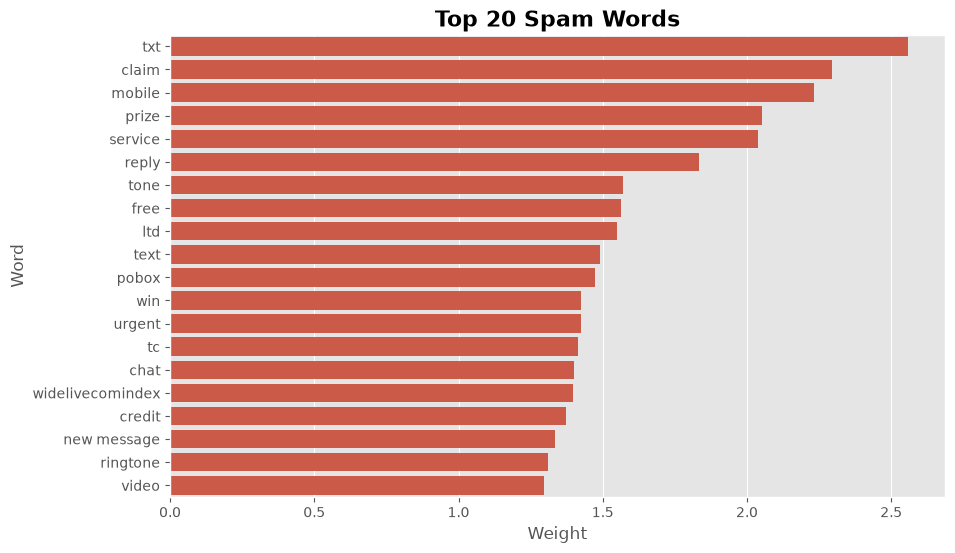

In [156]:
# ==========================================================
# STEP 122 : TOP SPAM WORDS
# ==========================================================

top_spam = spam_words.head(20)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_spam,
    x="Weight",
    y="Word"
)

plt.title(
    "Top 20 Spam Words",
    fontsize=16,
    fontweight="bold"
)

plt.show()

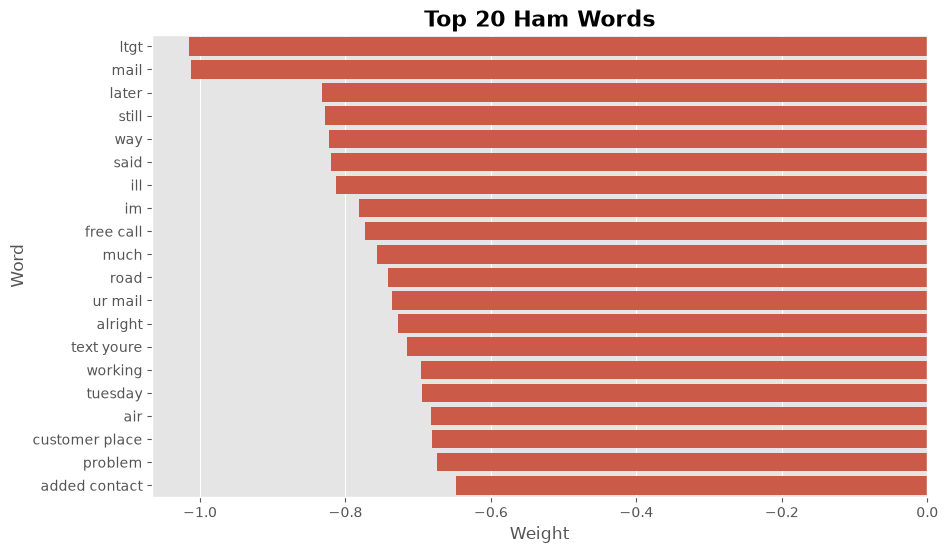

In [157]:
# ==========================================================
# STEP 123 : TOP HAM WORDS
# ==========================================================

top_ham = ham_words.head(20)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_ham,
    x="Weight",
    y="Word"
)

plt.title(
    "Top 20 Ham Words",
    fontsize=16,
    fontweight="bold"
)

plt.show()

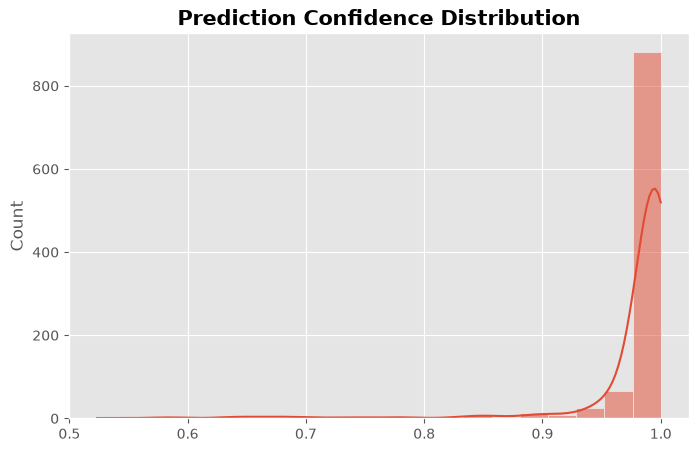

In [158]:
# ==========================================================
# STEP 124 : CONFIDENCE DISTRIBUTION
# ==========================================================

if hasattr(classifier, "predict_proba"):

    probabilities = spam_pipeline.predict_proba(X_test_text)

    confidence = probabilities.max(axis=1)

    plt.figure(figsize=(8,5))

    sns.histplot(
        confidence,
        bins=20,
        kde=True
    )

    plt.title(
        "Prediction Confidence Distribution",
        fontsize=15,
        fontweight="bold"
    )

    plt.show()

else:

    print("Confidence plot skipped.")

In [159]:
# ==========================================================
# STEP 125 : ERROR ANALYSIS
# ==========================================================

results = pd.DataFrame({

    "Message": X_test_text.reset_index(drop=True),

    "Actual": y_test.reset_index(drop=True),

    "Predicted": pd.Series(
        spam_pipeline.predict(X_test_text)
    )

})

errors = results[
    results["Actual"] != results["Predicted"]
]

print("Total Errors:", len(errors))

display(errors.head(20))

Total Errors: 20


,Message,Actual,Predicted
105,recieve tone within next hr term condition ple...,1,0
168,hi ur lookin saucy daytime fun wiv busty marri...,1,0
230,asked mobile chatlines inclu free min india cu...,1,0
247,waiting machan call free,0,1
277,ok ur typical reply,0,1
308,hi lucy hubby meetins day fri b alone hotel u ...,1,0
326,missed call alert number called left message,1,0
327,k k sm chat,0,1
329,sm ac sun post helloyou seem cool,1,0
404,freemsg hey u got videopic fones reply wild tx...,1,0


In [160]:
# ==========================================================
# STEP 126 : CROSS VALIDATION
# ==========================================================

scores = cross_val_score(

    spam_pipeline,

    X,

    y,

    cv=5,

    scoring="f1"

)

print(scores)

print()

print("Average F1")

print(scores.mean())

[0.912      0.90082645 0.9218107  0.91358025 0.90688259]

Average F1
0.9110199967752333


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

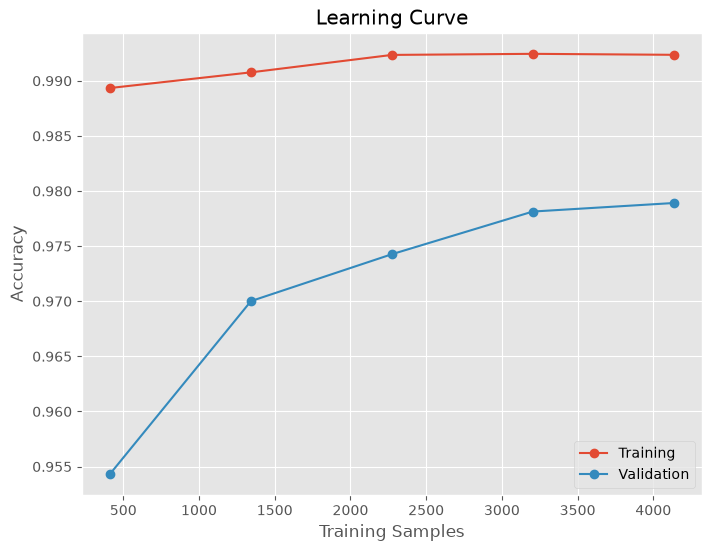

In [161]:
# ==========================================================
# STEP 127 : LEARNING CURVE
# ==========================================================

from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(

    spam_pipeline,

    X,

    y,

    cv=5,

    scoring="accuracy",

    train_sizes=np.linspace(0.1,1.0,5),

    n_jobs=-1

)

train_mean = train_scores.mean(axis=1)

test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))

plt.plot(

    train_sizes,

    train_mean,

    marker="o",

    label="Training"

)

plt.plot(

    train_sizes,

    test_mean,

    marker="o",

    label="Validation"

)

plt.legend()

plt.xlabel("Training Samples")

plt.ylabel("Accuracy")

plt.title("Learning Curve")

plt.show()

In [162]:
# ==========================================================
# STEP 128 : REAL PREDICTIONS
# ==========================================================

samples = [

    "Congratulations! You won a free iPhone.",

    "Meeting has been shifted to 5 PM.",

    "Claim your free vacation now.",

    "Can you call me tonight?",

    "URGENT! Your account has been suspended."

]

predictions = spam_pipeline.predict(samples)

for msg, pred in zip(samples, predictions):

    label = "Spam" if pred == 1 else "Ham"

    print(f"{label:5} | {msg}")

Spam  | Congratulations! You won a free iPhone.
Ham   | Meeting has been shifted to 5 PM.
Spam  | Claim your free vacation now.
Ham   | Can you call me tonight?
Ham   | URGENT! Your account has been suspended.


In [163]:
# ==========================================================
# STEP 129 : MODEL SUMMARY
# ==========================================================

summary = pd.DataFrame({

    "Metric":[

        "Algorithm",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Value":[

        best_model_name,

        accuracy_score(y_test, pipeline_predictions),

        precision_score(y_test, pipeline_predictions),

        recall_score(y_test, pipeline_predictions),

        f1_score(y_test, pipeline_predictions)

    ]

})

summary

,Metric,Value
0,Algorithm,SVM
1,Accuracy,0.980658
2,Precision,0.974359
3,Recall,0.870229
4,F1 Score,0.919355


In [164]:
# ==========================================================
# STEP 130 : SAVE RESULTS
# ==========================================================

summary.to_csv(

    "final_results.csv",

    index=False

)

print("Results Saved")

Results Saved


In [165]:
# ==========================================================
# STEP 131 : PROJECT COMPLETED
# ==========================================================

print("="*60)
print("SMS SPAM DETECTION PROJECT COMPLETED")
print("="*60)

print(f"Best Model : {best_model_name}")

print(f"Accuracy : {accuracy_score(y_test,pipeline_predictions):.4f}")

print(f"F1 Score : {f1_score(y_test,pipeline_predictions):.4f}")

print("="*60)

print("Project Ready for Deployment")

print("="*60)

SMS SPAM DETECTION PROJECT COMPLETED
Best Model : SVM
Accuracy : 0.9807
F1 Score : 0.9194
Project Ready for Deployment


In [166]:
# ==========================================================
# STEP 132 : IMPORT HYPERPARAMETER TUNING TOOLS
# ==========================================================

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [167]:
# ==========================================================
# STEP 133 : LOGISTIC REGRESSION TUNING
# ==========================================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", LogisticRegression(max_iter=3000, random_state=42))
])

lr_params = {
    "tfidf__max_features": [3000, 5000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "classifier__C": [0.1, 1, 10]
}

lr_grid = GridSearchCV(
    lr_pipeline,
    lr_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

lr_grid.fit(X_train_text, y_train)

print("Best Parameters:")
print(lr_grid.best_params_)

print("\nBest CV F1 Score:")
print(lr_grid.best_score_)

Best Parameters:
{'classifier__C': 10, 'tfidf__max_features': 3000, 'tfidf__ngram_range': (1, 2)}

Best CV F1 Score:
0.9023255633393864


In [168]:
# ==========================================================
# STEP 134 : LINEAR SVM TUNING
# ==========================================================

from sklearn.svm import LinearSVC

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", LinearSVC(random_state=42))
])

svm_params = {
    "tfidf__max_features": [3000, 5000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "classifier__C": [0.1, 1, 10]
}

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

svm_grid.fit(X_train_text, y_train)

print("Best Parameters:")
print(svm_grid.best_params_)

print("\nBest CV F1 Score:")
print(svm_grid.best_score_)

Best Parameters:
{'classifier__C': 1, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 1)}

Best CV F1 Score:
0.9115823462654751


In [169]:
# ==========================================================
# STEP 135 : MULTINOMIAL NB TUNING
# ==========================================================

from sklearn.naive_bayes import MultinomialNB

nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", MultinomialNB())
])

nb_params = {
    "tfidf__max_features": [3000, 5000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "classifier__alpha": [0.1, 0.5, 1.0]
}

nb_grid = GridSearchCV(
    nb_pipeline,
    nb_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

nb_grid.fit(X_train_text, y_train)

print("Best Parameters:")
print(nb_grid.best_params_)

print("\nBest CV F1 Score:")
print(nb_grid.best_score_)

Best Parameters:
{'classifier__alpha': 0.1, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 1)}

Best CV F1 Score:
0.9141556408636404


In [170]:
# ==========================================================
# STEP 136 : MODEL COMPARISON
# ==========================================================

models = {
    "Logistic Regression": lr_grid.best_estimator_,
    "Linear SVM": svm_grid.best_estimator_,
    "Multinomial NB": nb_grid.best_estimator_
}

results = []

for name, model in models.items():

    predictions = model.predict(X_test_text)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

comparison = pd.DataFrame(results)

comparison = comparison.sort_values(
    by="F1 Score",
    ascending=False
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
1,Linear SVM,0.980658,0.982609,0.862595,0.918699
2,Multinomial NB,0.978723,0.965812,0.862595,0.911290
0,Logistic Regression,0.976789,0.965217,0.847328,0.902439


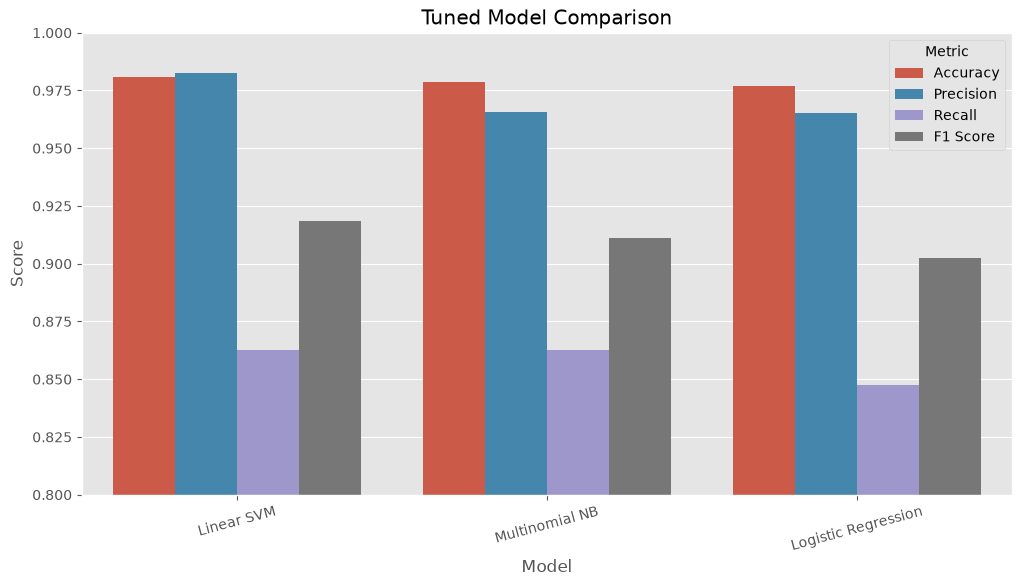

In [171]:
# ==========================================================
# STEP 137 : PERFORMANCE VISUALIZATION
# ==========================================================

comparison_plot = comparison.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=comparison_plot,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Tuned Model Comparison")

plt.xticks(rotation=15)

plt.ylim(0.8, 1.0)

plt.show()

In [172]:
# ==========================================================
# STEP 138 : FINAL MODEL
# ==========================================================

best_model = comparison.iloc[0]["Model"]

print("Best Model Selected:", best_model)

Best Model Selected: Linear SVM


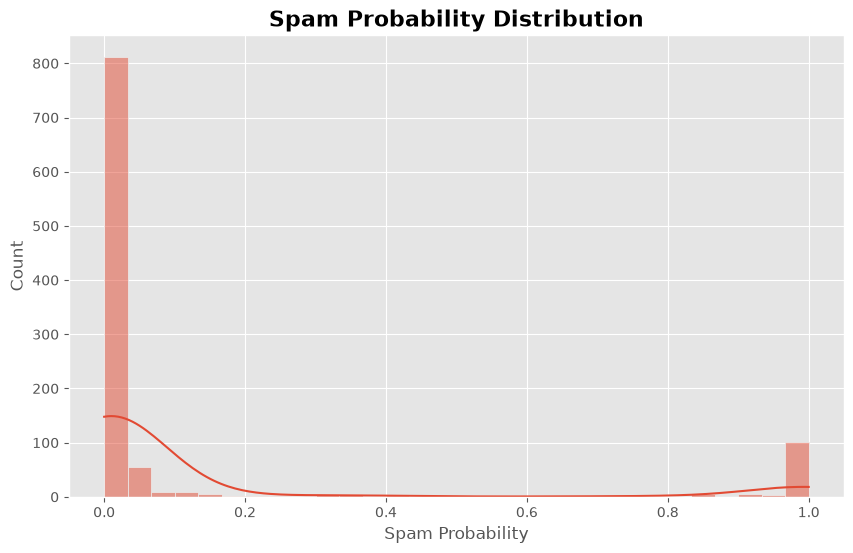

In [173]:
# ==========================================================
# STEP 139 : PREDICTION PROBABILITY DISTRIBUTION
# ==========================================================

classifier = spam_pipeline.named_steps["classifier"]

if hasattr(classifier, "predict_proba"):

    probabilities = spam_pipeline.predict_proba(X_test_text)[:, 1]

    plt.figure(figsize=(10,6))

    sns.histplot(
        probabilities,
        bins=30,
        kde=True
    )

    plt.title(
        "Spam Probability Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Spam Probability")

    plt.ylabel("Count")

    plt.show()

else:

    print("Current classifier does not support probability prediction.")

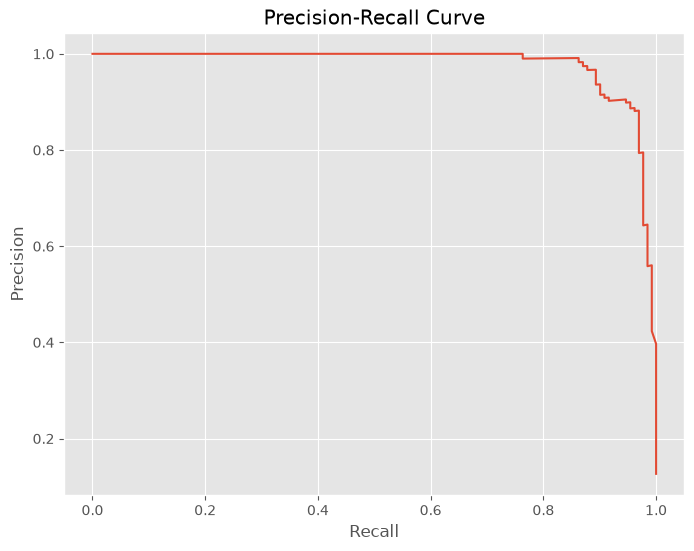

In [174]:
# ==========================================================
# STEP 140 : PRECISION-RECALL CURVE
# ==========================================================

from sklearn.metrics import precision_recall_curve

if hasattr(classifier, "predict_proba"):

    probabilities = spam_pipeline.predict_proba(X_test_text)[:,1]

    precision, recall, thresholds = precision_recall_curve(
        y_test,
        probabilities
    )

    plt.figure(figsize=(8,6))

    plt.plot(recall, precision)

    plt.title("Precision-Recall Curve")

    plt.xlabel("Recall")

    plt.ylabel("Precision")

    plt.grid(True)

    plt.show()

else:

    print("Precision-Recall curve unavailable.")

In [175]:
# ==========================================================
# STEP 141 : BEST THRESHOLD
# ==========================================================

from sklearn.metrics import f1_score

if hasattr(classifier, "predict_proba"):

    probabilities = spam_pipeline.predict_proba(X_test_text)[:,1]

    thresholds = np.arange(0.10,0.91,0.01)

    scores = []

    for threshold in thresholds:

        predictions = (probabilities >= threshold).astype(int)

        scores.append(
            f1_score(
                y_test,
                predictions
            )
        )

    best_index = np.argmax(scores)

    best_threshold = thresholds[best_index]

    print("Best Threshold:", best_threshold)

    print("Best F1:", scores[best_index])

else:

    print("Threshold tuning unavailable.")

Best Threshold: 0.4799999999999998
Best F1: 0.9285714285714286


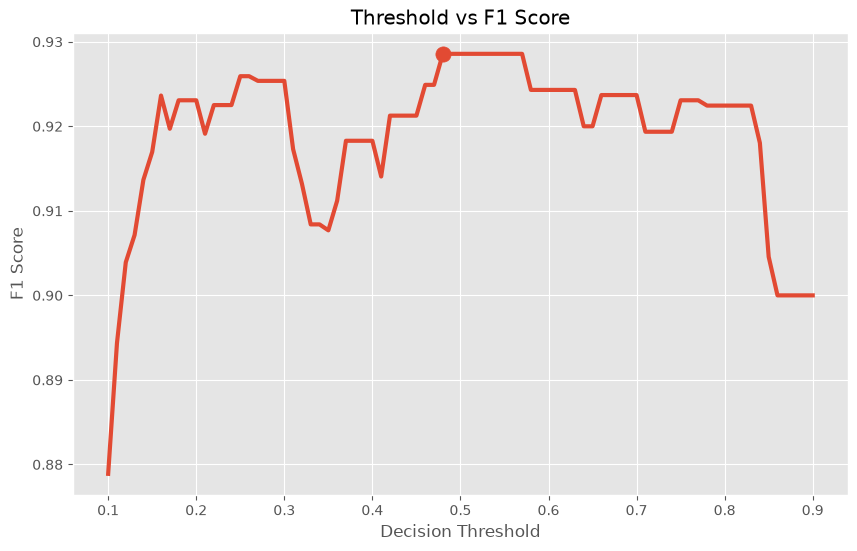

In [176]:
# ==========================================================
# STEP 142 : THRESHOLD ANALYSIS
# ==========================================================

plt.figure(figsize=(10,6))

plt.plot(
    thresholds,
    scores,
    linewidth=3
)

plt.scatter(
    best_threshold,
    scores[best_index],
    s=120
)

plt.title("Threshold vs F1 Score")

plt.xlabel("Decision Threshold")

plt.ylabel("F1 Score")

plt.grid(True)

plt.show()

In [177]:
# ==========================================================
# STEP 143 : FALSE POSITIVES
# ==========================================================

predictions = spam_pipeline.predict(X_test_text)

analysis = pd.DataFrame({

    "Message": X_test_text.reset_index(drop=True),

    "Actual": y_test.reset_index(drop=True),

    "Prediction": predictions

})

false_positive = analysis[

    (analysis["Actual"]==0) &
    (analysis["Prediction"]==1)

]

print("False Positives")

display(false_positive.head(20))

False Positives


,Message,Actual,Prediction
247,waiting machan call free,0,1
277,ok ur typical reply,0,1
327,k k sm chat,0,1


In [178]:
# ==========================================================
# STEP 144 : FALSE NEGATIVES
# ==========================================================

false_negative = analysis[

    (analysis["Actual"]==1) &
    (analysis["Prediction"]==0)

]

print("False Negatives")

display(false_negative.head(20))

False Negatives


,Message,Actual,Prediction
105,recieve tone within next hr term condition ple...,1,0
168,hi ur lookin saucy daytime fun wiv busty marri...,1,0
230,asked mobile chatlines inclu free min india cu...,1,0
308,hi lucy hubby meetins day fri b alone hotel u ...,1,0
326,missed call alert number called left message,1,0
329,sm ac sun post helloyou seem cool,1,0
404,freemsg hey u got videopic fones reply wild tx...,1,0
437,babe u want dont u baby im nasty thing filthyg...,1,0
468,lost pound help,1,0
486,simpson movie released july name band died sta...,1,0


In [179]:
# ==========================================================
# STEP 145 : SAVE MISCLASSIFICATIONS
# ==========================================================

misclassified = analysis[

    analysis["Actual"] != analysis["Prediction"]

]

misclassified.to_csv(

    "misclassified_messages.csv",

    index=False

)

print("Misclassified messages exported.")

Misclassified messages exported.


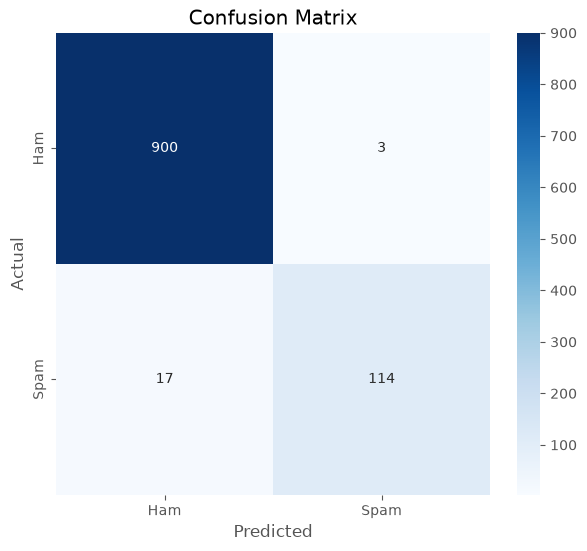

In [180]:
# ==========================================================
# STEP 146 : CONFUSION MATRIX
# ==========================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(

    y_test,

    predictions

)

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=["Ham","Spam"],

    yticklabels=["Ham","Spam"]

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [181]:
# ==========================================================
# STEP 147 : CLASSIFICATION REPORT
# ==========================================================

from sklearn.metrics import classification_report

print(

    classification_report(

        y_test,

        predictions,

        target_names=["Ham","Spam"]

    )

)

              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       903
        Spam       0.97      0.87      0.92       131

    accuracy                           0.98      1034
   macro avg       0.98      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



In [182]:
# ==========================================================
# STEP 148 : SAVE FINAL REPORT
# ==========================================================

report = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "Best Threshold"

    ],

    "Value":[

        accuracy_score(y_test,predictions),

        precision_score(y_test,predictions),

        recall_score(y_test,predictions),

        f1_score(y_test,predictions),

        best_threshold if "best_threshold" in globals() else np.nan

    ]

})

report.to_csv(

    "final_model_report.csv",

    index=False

)

print("Final report saved.")

Final report saved.


In [183]:
# ==========================================================
# STEP 149 : FINAL SUMMARY
# ==========================================================

print("="*70)

print("SMS SPAM DETECTION PROJECT")

print("="*70)

print(f"Final Model : {best_model_name}")

print(f"Accuracy    : {accuracy_score(y_test,predictions):.4f}")

print(f"Precision   : {precision_score(y_test,predictions):.4f}")

print(f"Recall      : {recall_score(y_test,predictions):.4f}")

print(f"F1 Score    : {f1_score(y_test,predictions):.4f}")

if "best_threshold" in globals():

    print(f"Threshold   : {best_threshold:.2f}")

print("="*70)

SMS SPAM DETECTION PROJECT
Final Model : SVM
Accuracy    : 0.9807
Precision   : 0.9744
Recall      : 0.8702
F1 Score    : 0.9194
Threshold   : 0.48
